# Setup

Install in R:
```
install.packages("BiocManager")
BiocManager::install(c("edgeR", "BiocParallel", "RhpcBLASctl"))
```

Install

```pip install toytree ete4 pybiomart```

---

Senmayo [gene set](https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO)

## Options & Data

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import re
import pickle
import matplotlib.pyplot as plt
import warnings
import ipynbname
import logging
import seaborn as sns
from scipy.sparse import issparse
from pymer4.models import lmer, lm, glmer, compare
from pymer4 import config
import polars
import statsmodels.api as sm
import senepy
import gseapy as gp
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import scflow
from scflow.ax import find_senescence_genes, run_senepy

# Display/Environment Settings
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
warnings.filterwarnings("ignore", message=".*ast.Ellipsis is deprecated.*")
config.PANDAS_BACKEND = True
warnings.filterwarnings("ignore", message=".*vert.*will be deprecated.*")
pd.set_option("display.max_rows", 500)  # or None for unlimited rows
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 300)
warnings.filterwarnings(
    "ignore", message="Bitwise inversion '~' on bool is deprecated",
    category=DeprecationWarning
)

# Datasets
batches = ["OSD-927", "OSD-928", "OSD-929", "OSD-930", "OSD-931", "OSD-932"]

# Process Options
ncpus = os.cpu_count() - 1
overwrite = True

# If You Want Results Emailed (Will Overwrite HTML Regardless of `overwite`)
cur_file = os.path.join(os.path.abspath(""), f"{ipynbname.name()}.ipynb")
html_out = os.path.splitext(cur_file)[0] + ".html"
email = "elizabeth.aslinger@aya.yale.edu"  # set email to None to skip

# Cell Type Label Column
col_celltype = "annotation_scanvi"
# col_celltype = "annotation_by_overlap"
# col_celltype = "annotation_predicted_labels_collapsed"
cols_cct = ["annotation_scanvi", "annotation_predicted_labels_collapsed"]
# cols_cct = ["annotation_by_overlap", "annotation_scanvi"]
# use_hierarchy = False

# Metadata Information
species = "Mouse"
col_sample, col_batch = "Subject", "Batch"
col_subject = "Subject"
col_cellsort = "CellSort"
# col_region = "Age"
col_region = "Region"
col_condition = "Condition"
group_order = ["Ground Control | Hippocampus", "Space Flight | Hippocampus",
               "Ground Control | Cerebellum", "Space Flight | Cerebellum",
               "Ground Control | Forebrain", "Space Flight | Forebrain"]
keys = {col_condition: dict(key_control="Ground Control",
                            key_treatment="Space Flight"),
        col_region: dict(key_control="Cerebellum",
                         key_treatment="Hippocampus"),
        # col_age: dict(key_control="3 Weeks",
        #               key_treatment="8 Weeks"),
        col_batch: dict(key_control=group_order[0],
                        key_treatment=group_order[1:])}
palette = {col_condition: {keys[col_condition]["key_control"]: "b",
                           keys[col_condition]["key_treatment"]: "r"},
           col_region: {keys[col_region]["key_control"]: "g",
                        keys[col_region]["key_treatment"]: "y"},
        #    col_age: {keys[col_region]["key_control"]: "g",
        #              keys[col_region]["key_treatment"]: "y"},
           col_batch: dict(zip(group_order, ["c", "b", "tab:pink", "r"]))}

# Scoring Metrics
sen_metrics = ["senmayo", "markers"]
# sen_metrics = ["senepy", "senmayo"]
# use_metric = "senmayo"
use_metric = "markers"
percentile = 2

# File Input & Output
file_path = f"data/{'_'.join(batches)}_integrated.h5ad"
file_path_new = os.path.splitext(file_path)[0] + "_analyzed.h5ad"

# Load Data
self = scflow.Rna(file_path, col_sample=col_sample, col_batch=col_batch,
                  col_celltype=col_celltype)  # data
self.rna.obs.loc[:, col_batch] = self.rna.obs[col_batch].astype(
    pd.CategoricalDtype(categories=group_order, ordered=True))
# self.rna = self.rna[:, self.rna.var.mt == False]  # snRNA-seq so remove MT
# self.rna = self.rna[:, self.rna.var.ribo == False]  # snRNA-seq so remove RB
self.rna.obs.loc[:, "Spaceflight"] = (self.rna.obs[col_condition] == keys[
    col_condition]["key_treatment"]).astype(int)  # 1 vs. 0 spaceflight
self.rna.X = self.rna.layers["log1p"].copy()
self.rna.raw = None

# Display Object
print(self.rna)
print(self.rna.obs.groupby(col_sample).describe())
self.rna.obs

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/senepy/load_hubs.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/marshmallow/__init__.py:17: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  __version_info__ = tuple(LooseVersion(__version__).version)
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/marshmallow/fields.py:198: RemovedInMarshmallow4Warning: Passing field metadata as a keyword arg is deprecated. Use the explicit `metadata=...` argument instead.
  warnings.warn(


AnnData object with n_obs × n_vars = 127665 × 16164
    obs: 'batch', 'Subject', 'Source Name', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Factor Value[Spaceflight]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Age]', 'Unit', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Material Type]', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Animal Source]', 'Protocol REF', 'Parameter Value[Diet]', 'Parameter Value[Feeding Schedule]', 'Parameter Value[duration]', 'Unit.1', 'Term Source REF.7', 'Term Accession Number.7', 'Parameter Value[light cycle]', 'Parameter Value[habitat]', 'Parameter Value[Enrichment material]', 'Protocol REF.1', 'Parameter Value[Euthanasia Location]', 'Parameter Val

,batch,Subject,Source Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Genotype],Term Source REF.2,Term Accession Number.2,Characteristics[Sex],Term Source REF.3,Term Accession Number.3,Factor Value[Spaceflight],Term Source REF.4,Term Accession Number.4,Factor Value[Age],Unit,Term Source REF.5,Term Accession Number.5,Characteristics[Material Type],Term Source REF.6,Term Accession Number.6,Characteristics[Animal Source],Protocol REF,Parameter Value[Diet],Parameter Value[Feeding Schedule],Parameter Value[duration],Unit.1,Term Source REF.7,Term Accession Number.7,Parameter Value[light cycle],Parameter Value[habitat],Parameter Value[Enrichment material],Protocol REF.1,Parameter Value[Euthanasia Location],Parameter Value[Dissection Condition],Parameter Value[Euthanasia Method],Parameter Value[Sample Preservation Method],Term Source REF.8,Term Accession Number.8,Parameter Value[Time between landing to euthanasia],Unit.2,Term Source REF.9,Term Accession Number.9,Raw Data File,Group,CellSort,Brain_Region,n_cells_original_Source Name,kws_pp_Source Name,n_genes_by_counts,total_counts,log1p_n_genes_by_counts,log1p_total_counts,total_counts_mt,pct_counts_mt,log1p_total_counts_mt,total_counts_ribo,pct_counts_ribo,log1p_total_counts_ribo,total_counts_hb,pct_counts_hb,log1p_total_counts_hb,n_counts,n_genes,doublet_score,predicted_doublet,leiden_individual_res0.7dist0.5,annotation_by_markers_individual_res0.7dist0.5,annotation_by_markers_individual_heterogeneous_collapsed,leiden_individual,annotation_by_markers_individual,kws_cluster_individual,annotation_scanvi,kws_integrate,leiden,leiden_resolution,leiden_n_neighbors,leiden_min_dist,annotation_by_overlap,predicted_labels,majority_voting,majority_voting_probabilities,majority_voting_short,annotation_majority_voting,annotation_predicted_labels,annotation_predicted_labels_collapsed,Age,Condition,n_cells_original_sample,Region,Batch,Spaceflight
AAACCCACACCATATG-1_HC_LAR_19_OSD-927,OSD-927,HC_LAR_19,HC_LAR_19_OSD-927,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON/10090,BALB/cAnNTac,OSD,https://osdr.nasa.gov/,Wild Type,NCIT,http://purl.obolibrary.org/obo/NCIT_C62195,Female,MESH,http://purl.bioontology.org/ontology/MESH/D005260,Ground Control,OSD,https://osdr.nasa.gov/,8,month,UO,http://purl.obolibrary.org/obo/UO_0000035,myeloid cerebellum,OSD,https://osdr.nasa.gov/,Taconic Biosciences,Animal Husbandry,Nutrient Upgraded Rodent Food Bar (NuRFB),ad libitum,40,day,UO,http://purl.obolibrary.org/obo/UO_0000033,12 h light/dark cycle,Rodent Flight Hardware (Transporter and Habitat),Hut,sample collection,On Earth,Upon euthanasia,"Bilateral thoracotomy with sedation, Cardiac puncture with sedation, Inhalation of Isoflurane",fresh specimen,OBI,http://purl.obolibrary.org/obo/OBI_0000971,2 - 4,day,UO,http://purl.obolibrary.org/obo/UO_0000033,"GLDS-755_scRNA-Seq_SRX28491902_R1_raw.fastq.gz, GLDS-755_scRNA-Seq_SRX28491902_R2_raw.fastq.gz",Ground Control | 8 Weeks,myeloid,cerebellum,5546,"{'min_max_genes': [499.0, None], 'min_max_cells': [1, None], 'max_mt': 29.732372760772705, 'min_...",1779,3576.0,7.484369,8.182280,47.0,1.314318,3.871201,31.0,0.866890,3.465736,0.0,0.000000,0.000000,3576.0,1779,0.051318,False,2,Microglial,Microglial,2,Microglial,"{'resolution': 0.7, 'min_dist': 0.5, 'n_comps': 50}",Microglial,"{'col_celltype': 'annotation_by_markers_individual_heterogeneous_collapsed', 'flavor': 'scanvi',...",1,0.2,20,0.1,Microglial | Macrophage (M1) | Microglial (DAM),334 Microglia NN,334 Microglia NN,9.999985e-01,Microglia NN,Microglia,Microglia,Microglia,8 Weeks,Ground Control,5546,Cerebellum,Ground Control | Cerebellum,0
AAACCCACACTATCGA-1_HC_LAR_19_OSD-927,OSD-927,HC_LAR_19,HC_LAR_19_OSD-927,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON/10090,BALB/cAnNTac,OSD,https://osdr.nasa.gov/,Wild Type,NCIT,http://purl.obolibrary.org/obo/NCIT_C62195,Female,MESH,http://pu

## Data Descriptives

In [3]:
%matplotlib inline

# Detect Metadata Columns in AnnData Object
metadata_cols = self.rna.obs.groupby(col_sample).apply(
    lambda x: list(x.columns[np.where(
        x.apply(lambda y: len(y.unique()) ==  1))[0]]))
metadata_cols = [x for x in metadata_cols.explode().unique() if all((
    x in metadata_cols.loc[i] for i in metadata_cols.index.values))]

# Value Counts for Categorical Variables
metadata_cols_category = self.rna.obs[metadata_cols].dtypes[((
    self.rna.obs[metadata_cols].dtypes == "category") | (self.rna.obs[
        metadata_cols].apply(lambda x: len(x.unique()) < 6))) & (self.rna.obs[
            metadata_cols].apply(lambda x: len(x.unique()) > 1))].index
for x in metadata_cols_category:
    print(x, "\n\n", self.rna.obs[x].value_counts(), "\n\n")
    if col_batch is not None:  # by batch
        if x != col_batch:
            print(x, "\n\n", self.rna.obs[[x, col_batch]].groupby(
                col_batch).value_counts(), "\n\n")

# Descriptives for Continuous Variables
print(self.rna.obs[self.rna.obs.columns.difference(
    metadata_cols_category)].describe())
# if col_batch is not None:  # by batch
#     print(self.rna.obs[list(self.rna.obs.columns.difference(
#         metadata_cols_category)) + [col_batch]].groupby(
#             col_batch).describe())

# Cells per Cluster
perc_clusters = round(100 * self.rna.obs.groupby(col_sample).value_counts(
    [col_celltype], normalize=True).unstack(1), 2)
print(f"\n\n*** Cell Composition (%) ***\n\n{perc_clusters}")

# Number of Cells
n_cells = self.rna.obs.groupby(col_sample).apply(
    lambda x: x.n_cells_original_sample.unique()[0],
    include_groups=False).to_frame("Original Cell N").join(
        self.rna.obs.groupby(col_sample).apply(
            lambda x: x.shape[0], include_groups=False).to_frame("N Cells"))
n_cells.loc[:, "Percent_Filtered"] = round(100 * (1 - n_cells[
    "N Cells"] / n_cells["Original Cell N"]), 2)
print("\n\n", n_cells.sort_values("Percent_Filtered"))

/tmp/ipykernel_2393249/3770444881.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metadata_cols = self.rna.obs.groupby(col_sample).apply(


Subject 

 Subject
HC_LAR_19    22882
HC_LAR_10    21495
HC_LAR_09    17638
HC_LAR_20    15788
FL_LAR_19    15065
FL_LAR_20    14827
FL_LAR_10    10243
FL_LAR_09     9727
Name: count, dtype: int64 


Subject 

 Batch                         Subject  
Ground Control | Hippocampus  HC_LAR_10    8562
                              HC_LAR_19    7474
                              HC_LAR_09    6720
                              HC_LAR_20    5606
                              FL_LAR_09       0
                              FL_LAR_10       0
                              FL_LAR_19       0
                              FL_LAR_20       0
Space Flight | Hippocampus    FL_LAR_20    4743
                              FL_LAR_10    2961
                              FL_LAR_19    2465
                              FL_LAR_09    2069
                              HC_LAR_09       0
                              HC_LAR_10       0
                              HC_LAR_19       0
                             

## Cell Type Annotations

In [127]:
if col_cellsort in self.rna.obs:
    for x in cols_cct:
        print(f"\n\n*** Cell Type Annotation: {x} ***\n\n")
        print(self.rna.obs[[col_cellsort, x]].groupby(col_cellsort).apply(
            lambda q: round(100 * q.value_counts(normalize=True)),
            include_groups=False).unstack(0))

self.rna.obs[cols_cct].groupby(cols_cct[0]).apply(lambda x: round(
    100 * x.value_counts(normalize=True), 2), include_groups=False)



*** Cell Type Annotation: annotation_scanvi ***


CellSort           myeloid  non-myeloid
annotation_scanvi                      
Astrocyte              0.0         35.0
Endothelial            0.0         21.0
Macrophage (M1)        1.0          0.0
Microglial            73.0          0.0
Microglial (DAM)      26.0          0.0
Neuroepithelial        0.0          1.0
Neuron                 0.0         30.0
OPC                    0.0          4.0
Oligodendrocyte        0.0          6.0
Pericyte               0.0          3.0


*** Cell Type Annotation: annotation_predicted_labels_collapsed ***


CellSort                               myeloid  non-myeloid
annotation_predicted_labels_collapsed                      
Astrocyte                                  2.0         31.0
Dendritic                                  0.0          0.0
Lymphoid                                   0.0          1.0
Macrophage (BAM)                           0.0          1.0
Microglia                           

annotation_scanvi  annotation_predicted_labels_collapsed
Astrocyte          Astrocyte                                76.24
                   Neuroepithelial                           7.58
                   Vascular                                  6.73
                   Neuron                                    5.54
                   Microglia                                 1.30
                   Olfactory                                 0.86
                   Lymphoid                                  0.85
                   OPC                                       0.41
                   Oligodendrocyte                           0.41
                   Macrophage (BAM)                          0.04
                   Dendritic                                 0.02
                   Monocyte                                  0.02
Endothelial        Microglia                                48.60
                   Vascular                                 46.11
                   

## Get Marker Gene Sets

From Google Drive, except senmayo derived from file downloaded from
https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO.html
then created using:

```
from pybiomart import Server

senmayo = pd.read_csv("resources/SAUL_SEN_MAYO.v2025.1.Hs.tsv",
                      sep="\t", header=0)
senmayo = senmayo[senmayo.STANDARD_NAME == "GENE_SYMBOLS"]
senmayo = pd.Series({"Senmayo": senmayo.iloc[0, 1].split(
    ",")}, name="symbol").rename_axis("Gene_Set").explode().str.strip(
        ).replace("", np.nan).dropna().to_frame()
server = Server(host="http://www.ensembl.org")
mart = server.marts["ENSEMBL_MART_ENSEMBL"] # Access the Ensembl mart
human_dataset = mart.datasets["hsapiens_gene_ensembl"]
orthologs = human_dataset.query(attributes=[
    "external_gene_name", "mmusculus_homolog_associated_gene_name"])
orthologs = orthologs.dropna().set_index(orthologs.columns[0])
orthologs = orthologs.loc[orthologs.index.intersection(
    senmayo.symbol.to_list())].iloc[:, 0]
print(f"{orthologs.shape[0]} orthologs found out of"
      f" {len(senmayo.symbol.unique())} senmayo genes")
senmayo = senmayo.assign(symbol=senmayo.replace({"symbol": dict(zip(
    orthologs.index, orthologs.values))}))
senmayo.to_csv("gene_sets/senmayo.csv")
```

(Also could use `scflow.tl.convert_gene_species(senmayo.symbol.to_list())`)

Certain gene sets created from Google Drive ADBR AWG > Projects > White Matter > Gene Sets files (with the suffix = "_adjusted") were modified for consistency, e.g.,

```
pd.read_csv("gene_sets/_iron_genes_gmt_out.csv", index_col=[
    0, 1]).rename_axis(["row_id", "pathway"]).stack().to_frame(
        "symbol").reset_index(-1, drop=True).reset_index().to_csv(
            "gene_sets/_iron_genes_gmt_out_adjusted.csv")
```


### *A Priori*

In [4]:
mks = [pd.read_csv(os.path.join("gene_sets", i)).dropna(
    how="all", axis=1).assign(Source_File=i) for i in os.listdir("gene_sets")]
mks = [x.assign(Gene_Set=x["Source_File"].iloc[0].split("_2025")[0]) if (
    "pathway" in x) else x for x in mks]
mks = pd.concat(mks).drop("Unnamed: 0", axis=1).drop("row_id", axis=1)
mks = mks[mks.symbol.isin(self.rna.var_names)]
mks = mks[["Gene_Set", "symbol"]].set_index("Gene_Set").groupby(
    "Gene_Set").apply(lambda x: x["symbol"].to_list())
marker_genes_dict = dict(mks)
marker_gene_sets = mks.copy()
print(marker_gene_sets)

Gene_Set
GOBP_CELLULAR_RESPONSE_TO_IRON_ION                                                                                                                                                                                                                                  [B2m, Hfe, Ireb2, Tfrc, Trf]
GOBP_CENTRAL_NERVOUS_SYSTEM_MYELIN_FORMATION                                                                                                                                                                                                [Abca2, Ckap5, Cntn1, Ercc2, Mag, Mios, Tenm4, Tlr2]
GOBP_INTRACELLULAR_IRON_ION_HOMEOSTASIS                                                                                                                                                      [Abcb7, Aco1, Alas2, Atp13a2, Atp6ap1, Atp6v0a2, Atp6v0d1, Atp6v1a, Atp6v1g1, B2m, Bmyc, Bola2, ...
GOBP_IRON_COORDINATION_ENTITY_TRANSPORT                                                                                     

### Clusters in Data

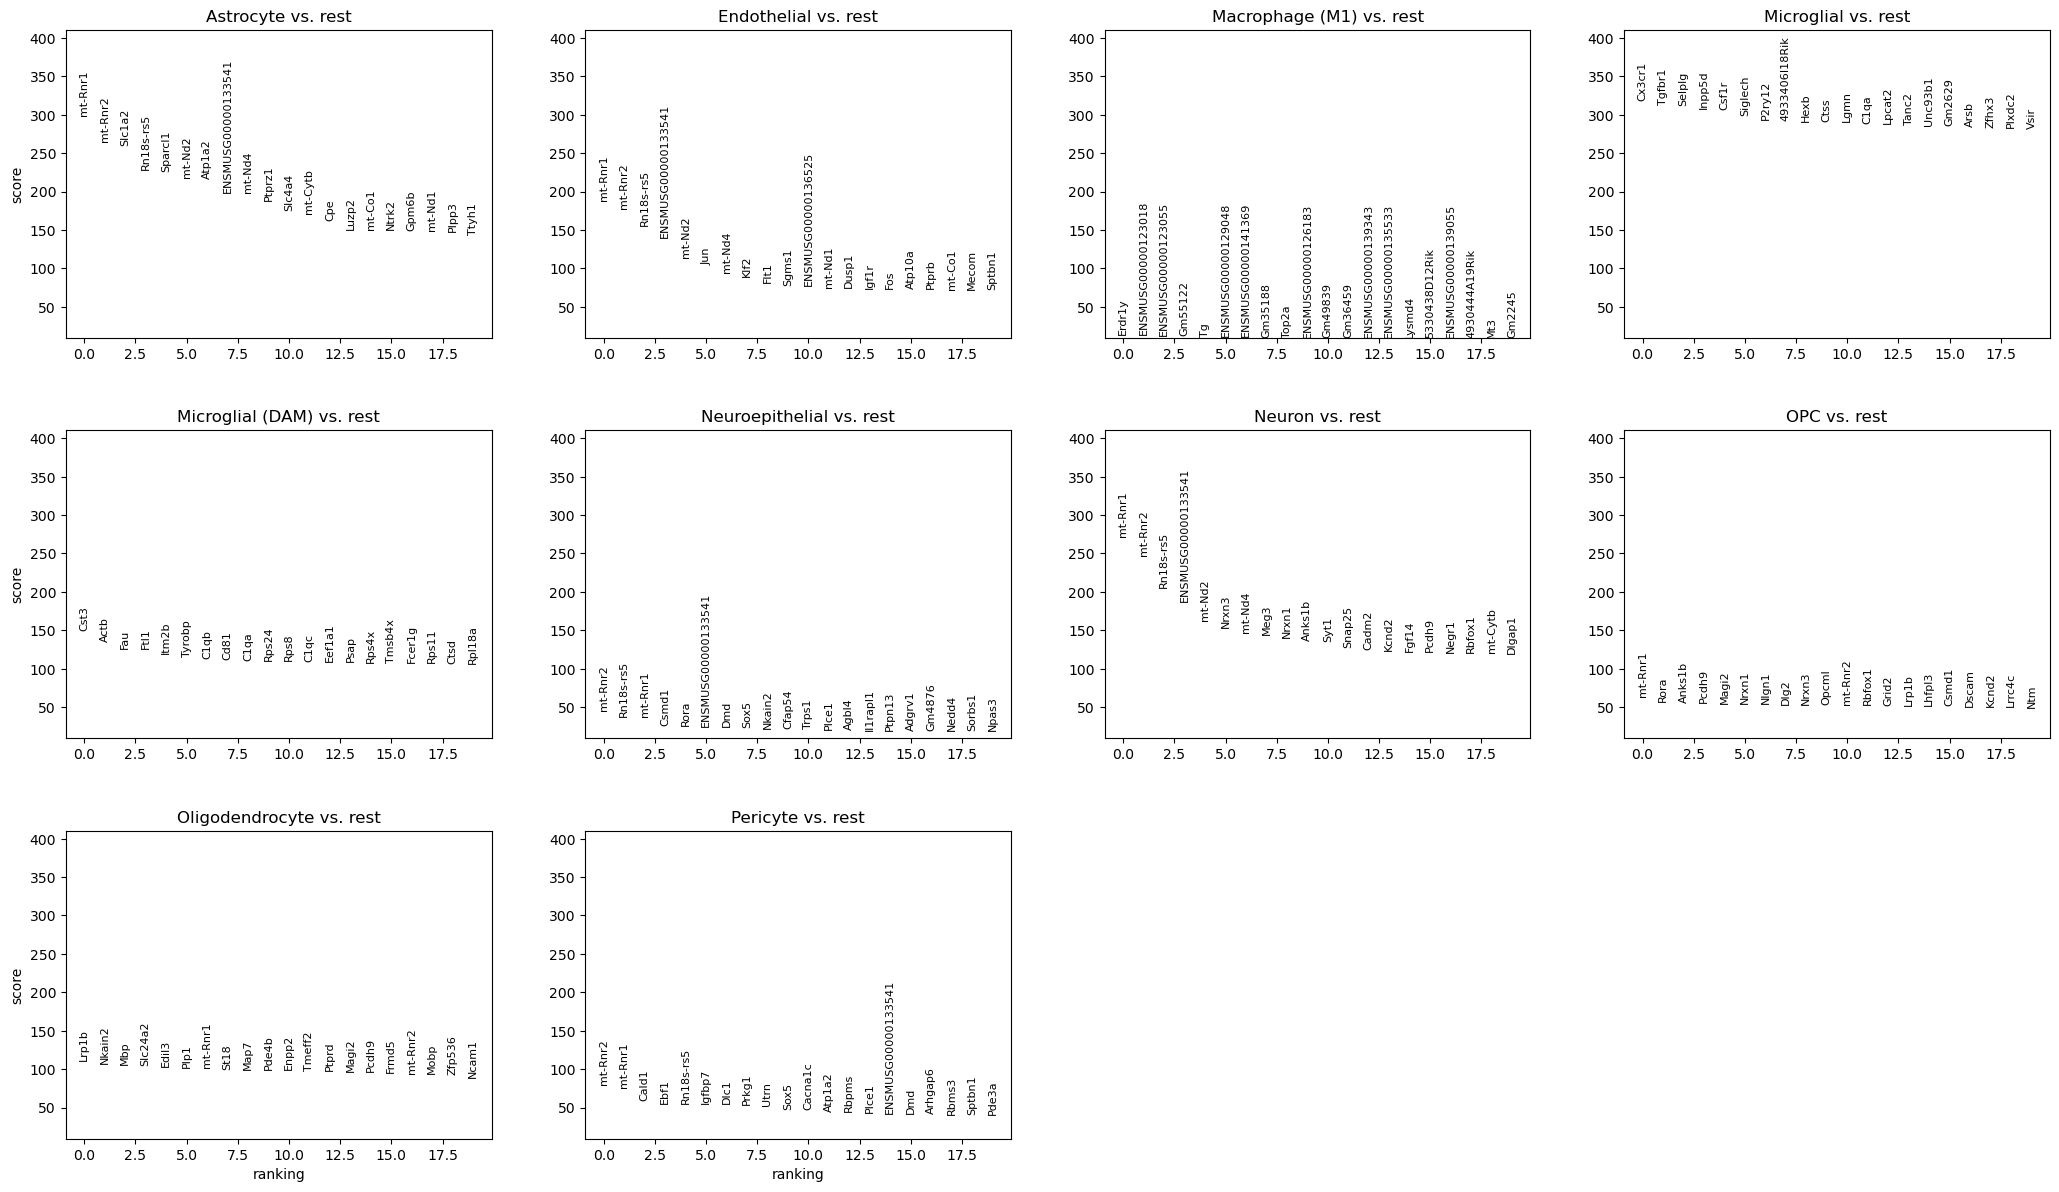

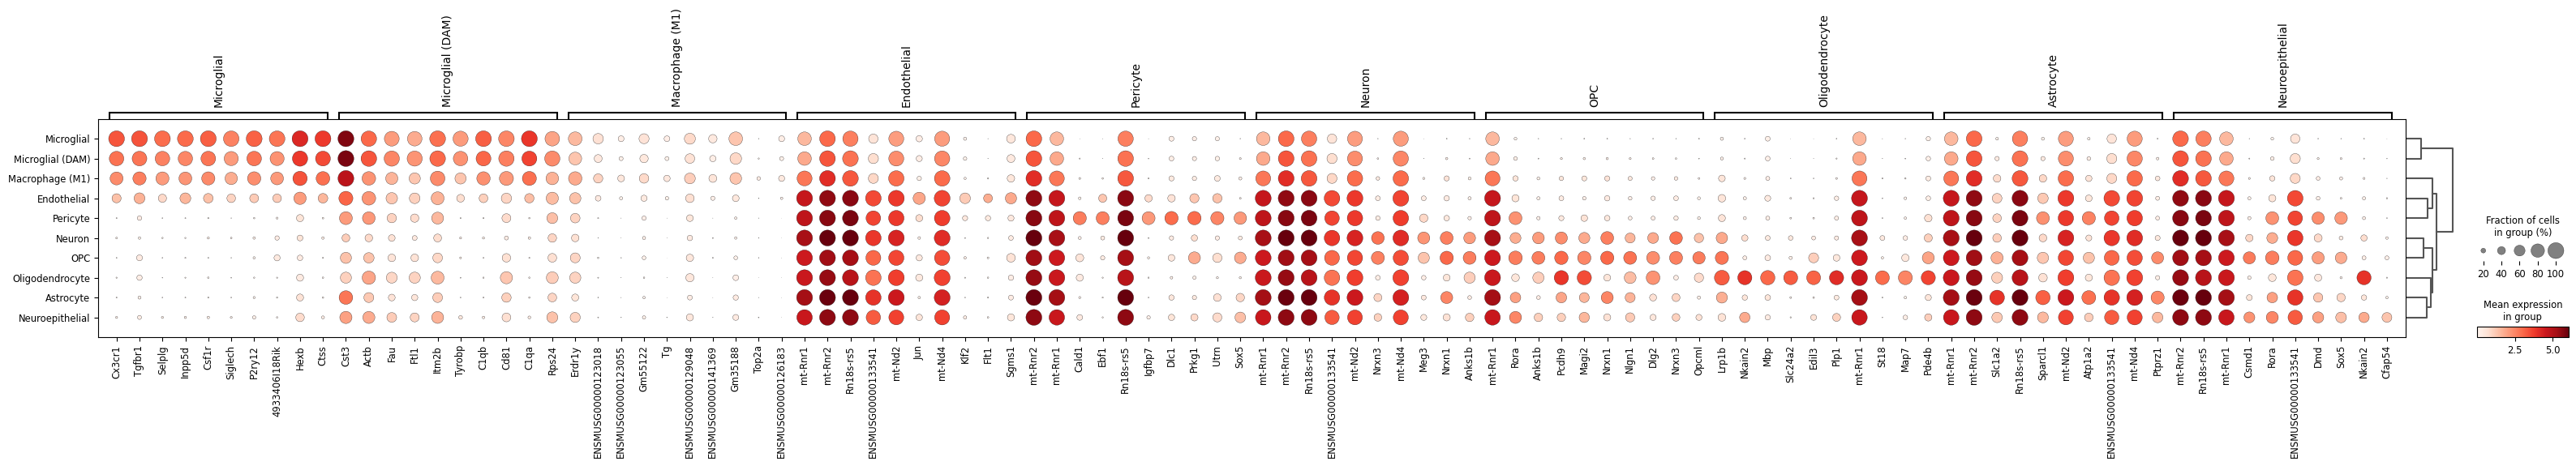

scores  logfoldchanges          pvals      pvals_adj  pct_nz_group  pct_nz_reference
annotation_scanvi annotation_scanvi names                                                                                                       
Astrocyte         Astrocyte         Astn2                48.683842        1.895094   0.000000e+00   0.000000e+00      0.319717          0.102489
                                    ENSMUSG00000127915   49.198124        1.988600   0.000000e+00   0.000000e+00      0.314490          0.160576
                                    Kcnj16               49.195496        2.783713   0.000000e+00   0.000000e+00      0.237604          0.070860
Endothelial       Endothelial       Sp100                40.503395        2.432892   0.000000e+00   0.000000e+00      0.278138          0.095178
                                    Garre1               42.128155        1.663516   0.000000e+00   0.000000e+00      0.416744          0.292559
                                    Sash1                42.358269        1.982004   0.000000e+00   0.000000e+00      0.349352          0.121517
Macrophage (M1)   Macrophage (M1)   Erdr1y               13.406932        1.014180   1.723632e-37   4.493675e-35      0.794151          0.681556
                                    ENSMUSG00000123018   13.370123        1.577443   2.710647e-37   6.954746e-35      0.485939          0.374022
                                    ENSMUSG00000123055   12.542710        1.877684   2.378350e-33   5.571543e-31      0.322835          0.170434
Microglial        Microglial        Sbno2                63.398911        1.158250   0.000000e+00   0.000000e+00      0.334661          0.148682
                                    Ggta1                64.576416        1.344249   0.000000e+00   0.000000e+00      0.277293          0.109197
                                    Snn                  64.582275        1.120466   0.000000e+00   0.000000e+00      0.363833          0.165492
Microglial (DAM)  Microglial (DAM)  Eef1a1              109.063164        1.191558   0.000000e+00   0.000000e+00      0.954167          0.765218
                                    Rps24               110.620682        1.290333   0.000000e+00   0.000000e+00      0.943722          0.742698
                                    C1qa                110.688972        1.723188   0.000000e+00   0.000000e+00      0.922260          0.657058
Neuroepithelial   Neuroepithelial   mt-Rnr2              45.464649        2.244209  3.758589e-201  1.972527e-199      0.998361          0.986439
                                    Rn18s-rs5            38.374210        2.680816  2.608590e-166  1.048887e-164      0.998361          0.971965
                                    mt-Rnr1              38.129841        2.728439  3.293189e-165  1.307890e-163      0.967213          0.870080
Neuron            Neuron            Trim9                47.182800        2.162765   0.000000e+00   0.000000e+00      0.294517          0.079424
                                    Slco3a1              46.315220        3.011157   0.000000e+00   0.000000e+00      0.218540          0.035012
                                    Lrfn5                46.320843        3.879190   0.000000e+00   0.000000e+00      0.188245          0.018810
OPC               OPC               mt-Rnr1              63.623161        2.628763   0.000000e+00   0.000000e+00      0.990190          0.869094
                                    Rora                 57.108105        4.023777   0.000000e+00   0.000000e+00      0.810334          0.245299
                                    Dscam                51.159264        6.981355   0.000000e+00   0.000000e+00      0.671681          0.036572
Oligodendrocyte   Oligodendrocyte   Unc5c                82.005005        5.623591   0.000000e+00   0.000000e+00      0.809261          0.074327
                                    Ptprk                80.878365        5.953379   0.000000e+00   0.000000e+00      0.793543          0.056156


In [5]:
self.find_markers(col_celltype=col_celltype)
df_celltype_markers = self.get_markers_df(
    n_genes=50, col_celltype=col_celltype,
    log2fc_threshold=1, p_threshold=1e-10)
df_celltype_markers.groupby(col_celltype).apply(lambda x: x.head(3))

# Regress Out?

In [6]:
# if vars_regress_out is not None:
#     self.rna.X = self.rna.layers["log1p"].copy()
#     sc.pp.regress_out(self.rna, vars_regress_out)
#     self.rna.layers["log1p"] = self.rna.X.copy()
#     pkg.pp.scale(self.rna, zero_center=True, max_value=10)
#     self.rna.layers["scaled"] = self.rna.X.copy()
#     self.rna.X = self.rna.layers["log1p"].copy()

# Score Senescence

## Run Scoring

If you want just to find the senescence-related genes, run:

```
tissue = "Brain"  # or whatever you want here
celltype = None  # or whatever you want here
genes_senepy, hubs, figs = find_senescence_genes(
    self.rna, species=species, tissue=tissue, celltype=celltype,
    overlap_threshold=0, literature_sources=None,
    sengpt_sources=True, plot=True, col_celltype=col_celltype
)  # find tissue- and/or cell type-specific genes
```

To see available hubs:

```
hubs = senepy.load_hubs(species=species)
hubs.metadata.set_index(["tissue", "cell"]).sort_index()
```

Other examples of arguments you could use:

```
# tissue = ["Brain", "Myeloid"]
# tissue = None

# celltype = "GABA interneuron"  # only human I think
# celltype = ["microglia", "t cell", "monocyte"]
# celltype = "microglia"
# celltype = "microglial cell"`

### Senepy

In [7]:
%%time

tissue = "Brain"
celltype = None  # use all cell types

if "senepy" in sen_metrics:
    self.rna.X = self.rna.layers["log1p"].copy()
    self.rna, genes_senepy, figs = run_senepy(
        self.rna, species=species, tissue=tissue, celltype=celltype,
        overlap_threshold=0, literature_sources=None,
        sengpt_sources=True, col_celltype=col_celltype,
        col_senscore="score_senepy", identifiers=[col_celltype],
        use_translator=True, plot=True, figsize=(20, 20),
        swap_axes=False, standard_scale="group", plot_layer="log1p"
    )  # find tissue- and/or cell type-specific genes
    self.rna.obs.loc[
        :, "score_senepy_original_scale"] = self.rna.obs.score_senepy
    self.rna.obs.loc[:, "score_senepy"] = np.log(
        self.rna.obs.score_senepy)  # log-transform senescence score
    self.rna.obs[["score_senepy"]]

CPU times: user 2 μs, sys: 2 μs, total: 4 μs
Wall time: 6.2 μs


### Senmayo

In [15]:
if "senmayo" in sen_metrics:
    sc.tl.score_genes(self.rna, marker_gene_sets.loc["Senmayo"],
                      ctrl_as_ref=True, ctrl_size=50, gene_pool=None,
                      n_bins=25, score_name="score_senmayo", random_state=0,
                      copy=False, layer="log1p", use_raw=False)

### Markers

https://pmc.ncbi.nlm.nih.gov/articles/PMC11737875/

In [33]:
self.rna.obs = self.rna.obs.join((self.get_gex_matrix(markers_snc, layer="counts") > 0).T.sum().to_frame("score_markers"))

ValueError: columns overlap but no suffix specified: Index(['score_markers'], dtype='object')

In [34]:
markers_snc = ["Cdkn1a", "Cdkn2a", "Cdkn2d", "H2ax"]
if "markers" in sen_metrics:
    if "score_markers" in self.rna.obs:
        self.rna.obs = self.rna.obs.drop("score_markers", axis=1)
    # sc.tl.score_genes(self.rna, ["Cdkn1a", "Cdkn2a", "Cdkn2d", "H2ax"],
    #                   ctrl_as_ref=True, ctrl_size=50, gene_pool=None,
    #                   n_bins=25, score_name="score_markers", random_state=0,
    #                   copy=False, layer="log1p", use_raw=False)
    self.rna.obs = self.rna.obs.join((self.get_gex_matrix(
        markers_snc, layer="counts") > 0).T.sum().to_frame("score_markers"))

## Label SnCs

### Define Snc Threshold & Label Cells

Based on percentile threshold derived from control group

In [35]:
# Determine Threshold
perc_s, perc = str(100 - percentile) + "%", 1 - (percentile / 100)
p_h = 3
perc_s_h, perc_h = str(100 - p_h) + "%", 1 - (p_h / 100)
print("Percentile for Threshold:", perc_s)
for u in sen_metrics:
    for x in [f"Senescence_Threshold_{u}", f"Senescence_Threshold_{u}_{p_h}"]:
        if x in self.rna.obs:
            self.rna.obs = self.rna.obs.drop(x, axis=1)
    self.rna.obs = self.rna.obs.join(self.rna.obs[self.rna.obs[
        col_batch] == keys[col_batch]["key_control"]].groupby(
            col_celltype).apply(lambda x: x[f"score_{u}"].describe(
                percentiles=[perc])[perc_s], include_groups=False).to_frame(
                    f"Senescence_Threshold_{u}"),
                on=col_celltype).loc[self.rna.obs.index]
    self.rna.obs = self.rna.obs.join(self.rna.obs[self.rna.obs[
        col_batch] == keys[col_batch]["key_control"]].groupby(
            col_celltype).apply(lambda x: x[f"score_{u}"].describe(
                percentiles=[perc_h])[perc_s_h],
                                include_groups=False).to_frame(
                                    f"Senescence_Threshold_{u}_{p_h}"),
                                on=col_celltype).loc[self.rna.obs.index]

# Binary CLassification
for x in sen_metrics:
    self.rna.obs.loc[:, f"Senescent_Cell_{x}"] = (self.rna.obs[
        f"score_{x}"] >= self.rna.obs[f"Senescence_Threshold_{x}"])
    self.rna.obs.loc[:, f"Senescent_Cell_{x}_{p_h}"] = (self.rna.obs[
        f"score_{x}"] >= self.rna.obs[f"Senescence_Threshold_{x}_{p_h}"])

# String Labels (for Plotting/Categorical Analysis)
for x in sen_metrics:
    self.rna.obs.loc[:, f"Senescent_Cell_Label_{x}"] = self.rna.obs[
        f"Senescent_Cell_{x}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_hierarchy_{x}"] = self.rna.obs[
        f"Senescent_Cell_{x}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_{x}_{p_h}"] = self.rna.obs[
        f"Senescent_Cell_{x}_{p_h}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_by_Type_{x}"] = self.rna.obs[
        f"Senescent_Cell_Label_{x}"].replace({
            "Senescent": "SnC ", "Non-Senescent": ""}) + self.rna.obs[
                col_celltype].astype(str)
    # self.rna.obs.loc[:, f"SnC_hierarchy_{x}"] = self.rna.obs[
    #     f"Senescent_Cell_Label_{x}"].replace({
    #         "Senescent": "SnC ", "Non-Senescent": ""}) + self.rna.obs[
    #             col_celltype + "_hierarchy"].astype(str)

# Descriptives
for x in sen_metrics:
    print(x, round(self.rna.obs[[
        f"Senescent_Cell_Label_{x}", col_celltype]].value_counts(
            normalize=True).sort_index() * 100, 1).unstack(0))
    print("\n\n", x, round(self.rna.obs.groupby(col_celltype)[[
        f"Senescent_Cell_Label_{x}"]].value_counts(
            normalize=True).sort_index() * 100, 1).unstack(0))

# Choose Metrics for Main Analysis
# for x in ["Senescent_Cell_Label", "Senescent_Cell", "SnC_hierarchy",
#             "Senescence_Threshold", "Senescent_Cell_Label_by_Type"]:
for x in ["Senescent_Cell_Label", "Senescent_Cell",
            "Senescence_Threshold", "Senescent_Cell_Label_by_Type"]:
    self.rna.obs.loc[:, x] = self.rna.obs[f"{x}_{use_metric}"]
self.rna.obs.loc[:, "senscore"] = self.rna.obs[f"score_{use_metric}"]
self.rna.obs.loc[
    :, f"Senescent_Cell_Label_by_Type_{use_metric}_{p_h}"] = self.rna.obs[
        f"Senescent_Cell_Label_{use_metric}_{p_h}"].replace({
            "Non-Senescent": "", "Senescent": "SnC "}).astype(
                str) + self.rna.obs[
                    col_celltype].astype(str)  # lower threshold SnC by type
genes = marker_gene_sets.loc["Senmayo"] if (
    use_metric == "senmayo") else markers_snc  # main senescence gene list

# Avoid Nesting Duplication Issues
# self.rna.obs.loc[:, "SnC_hierarchy"] = self.rna.obs[
#     "SnC_hierarchy"].replace({
#         "Neuron": "Neurons", "SnC Neuron": "SnC Neurons"})

Percentile for Threshold: 98%
senmayo Senescent_Cell_Label_senmayo  Non-Senescent  Senescent
annotation_scanvi                                     
Astrocyte                              11.2        0.2
Endothelial                             6.6        0.2
Macrophage (M1)                         0.7        0.0
Microglial                             48.4        0.6
Microglial (DAM)                       17.5        0.2
Neuroepithelial                         0.5        0.0
Neuron                                  9.9        0.1
OPC                                     1.2        0.0
Oligodendrocyte                         1.8        0.0
Pericyte                                0.9        0.0


 senmayo annotation_scanvi             Astrocyte  Endothelial  Macrophage (M1)  Microglial  Microglial (DAM)  Neuroepithelial  Neuron   OPC  Oligodendrocyte  Pericyte
Senescent_Cell_Label_senmayo                                                                                                         

### Label Batch/Cell-Specific Senescence Percentiles

In [ ]:
# for x in ["Senescence_Label", "Senescence_CellType"]:
#     if x in self.rna.obs:
#         self.rna.obs = self.rna.obs.drop(x, axis=1)

# # %ile Thresholds (Overall)
# thresh = self.rna.obs["score_senepy"].describe(
#     percentiles=[0.90, 0.95, 0.99])
# thres_ct =  self.rna.obs[["score_senepy", col_celltype]].groupby(
#     col_celltype).describe(percentiles=[0.90, 0.95, 0.99])["score_senepy"]

# sen = self.rna.obs["score_senepy"].apply(
#     lambda x: "Top 1%" if x >= float(thresh.loc["99%"]) else "Top 5%" if (
#         x >= float(thresh.loc["95%"])) else "Top 10%" if x >= float(
#             thresh.loc["90%"]) else "Bottom 90%").to_frame(
#                 "Senescence_Label").loc[self.rna.obs.index]
# self.rna.obs = self.rna.obs.join(sen).loc[self.rna.obs.index]

# # %ile Thresholds (by Cell Type)
# sct = self.rna.obs.groupby(
#     col_celltype).apply(lambda g: g["score_senepy"].apply(
#         lambda x: f"Top 1% {g.name}" if x >= float(thres_ct.loc[g.name][
#             "99%"]) else f"Top 5% {g.name}" if (x >= float(thres_ct.loc[
#                 g.name]["95%"])) else f"Top 10% {g.name}" if x >= float(
#                     thres_ct.loc[g.name]["90%"]) else g.name),
#                         include_groups=False)

# sct = sct.to_frame("Senescence_CellType").reset_index(0, drop=True)
# sct = sct.loc[self.rna.obs.index]
# self.rna.obs = self.rna.obs.join(sct).loc[self.rna.obs.index]

# for x in ["Senescence_Label", "Senescence_CellType"]:
#     self.rna.obs = self.rna.obs.assign(**{
#         x: self.rna.obs[x].astype("category")})

# high_sen_cts = [i for i in self.rna.obs["Senescence_CellType"].unique(
#     ) if " 1% " in i]

### Descriptives of SnCs

annotation_scanvi                     Astrocyte  Endothelial  Macrophage (M1)  Microglial  Microglial (DAM)  Neuroepithelial     Neuron        OPC  Oligodendrocyte    Pericyte
Region      Condition      Subject                                                                                                                                             
Cerebellum  Ground Control HC_LAR_09  10.344828     3.265306              NaN         NaN               NaN              NaN   2.704952   0.571429         8.000000   18.309859
                           HC_LAR_10  10.791367     3.703704         0.384615   18.244370         22.523585         7.692308   5.319149   0.000000        10.000000   21.052632
                           HC_LAR_19   9.357798     1.444043        14.166667   16.870416         20.084073        12.500000   4.177898   0.000000         2.970297   23.684211
                           HC_LAR_20  12.422360     2.094241         0.000000   17.327714         20.040486         0.00

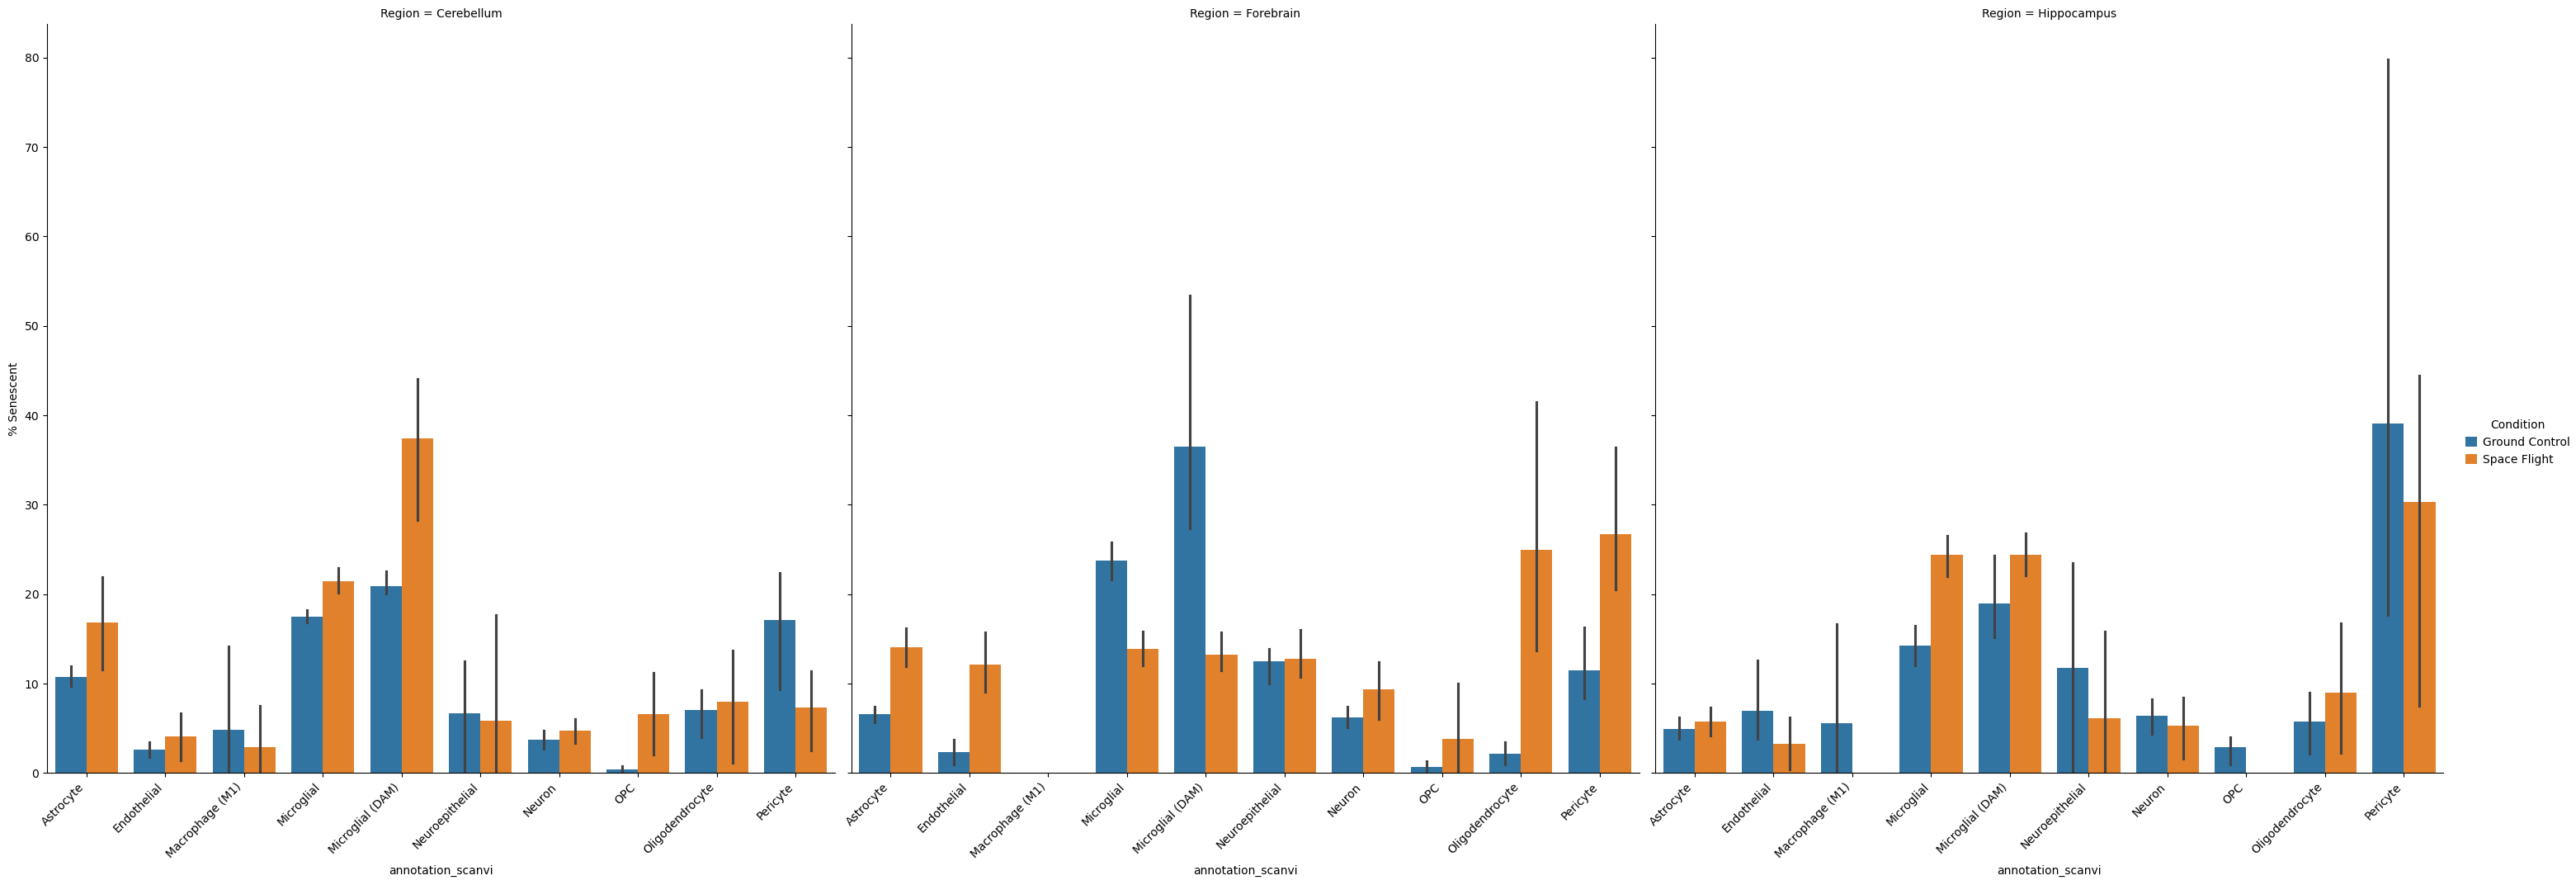

In [66]:
df_snc_burden = self.rna.obs.groupby([
    col_celltype, col_region, col_condition, col_subject]).apply(
        lambda x: 100 * x["Senescent_Cell"].astype(
            int).mean(), include_groups=False).unstack(col_celltype)
print(df_snc_burden, "\n\n\n")
print("Percent Senescent: \n\n", round(self.rna.obs.groupby([
    col_celltype, col_region, col_condition]).apply(
        lambda x: 100 * x["Senescent_Cell"].astype(
            int).mean(), include_groups=False).unstack(col_celltype), 2))
fig = sns.catplot(df_snc_burden.stack().to_frame("% Senescent"),
                  y="% Senescent", x=col_celltype, hue=col_condition,
                  col=col_region, kind="bar", height=10)
fig.set_xticklabels(rotation=45, horizontalalignment="right")

# Remove Cell Types with <2 SnCs

In [ ]:
snc_counts = self.rna.obs[[
    col_celltype, "Senescent_Cell_Label"]].value_counts().unstack(1)[
        "Senescent"].replace(np.nan, 0)
print(snc_counts.round(), "\n\n")
rm_cts = self.rna.obs[self.rna.obs["Senescent_Cell_Label_by_Type"].isin(
    snc_counts[snc_counts < 2].index.values)][col_celltype].unique()
print(f"Removing {list(rm_cts)}")
self.rna = self.rna[~self.rna.obs[col_celltype].isin(rm_cts)]

# SnC DEGs

## Overall

In [ ]:
p_threshold = 1e-10
lfc_threshold = 1
self.find_markers(col_celltype="Senescent_Cell_Label_by_Type")
df_snc_markers = {}
df_snc_markers["All"] = self.get_markers_df(
    n_genes=50, col_celltype="Senescent_Cell_Label_by_Type",
    log2fc_threshold=1, p_threshold=1e-10)
# print(df_snc_markers["All"].loc[pd.unique([
#     i[0] for i in df_snc_markers["All"].index.values if (
#         "SnC" in i[0])])].groupby("Senescent_Cell_Label_by_Type").apply(
#             lambda x: x.head(3)))
for x in self.rna.obs[col_celltype].unique():
    df_snc_markers[x] = self.find_markers(
        col_celltype="Senescent_Cell_Label_by_Type",
        reference=x, groups=[x, f"SnC {x}"], rankby_abs=True,
        inplace=False).reset_index(0, drop=True).assign(**{
            col_celltype: f"SnC {x}"}).reset_index().set_index([
                col_celltype, "names"])
df_snc_markers = pd.concat(df_snc_markers, names=["Comparison"])
df_snc_markers = df_snc_markers.rename_axis([
    "Comparison", col_celltype, "names"]).rename({
        "logfoldchanges": "log_fc"}, axis=1).assign(
            log_fc_abs=df_snc_markers["logfoldchanges"].abs())
df_snc_markers_top = df_snc_markers[df_snc_markers.pvals_adj < p_threshold]
df_snc_markers_top = df_snc_markers_top[
    df_snc_markers.log_fc_abs >= lfc_threshold]
df_snc_markers_top = df_snc_markers_top.groupby([
    "Comparison", col_celltype]).apply(
        lambda x: x.assign(scores_abs=x.scores.abs()).sort_values(
            "scores_abs", ascending=False).head(20),
        include_groups=False).reset_index([0, 1], drop=True)

## By Group

### Find Snc versus Non-SnC DEGs by Group

In [ ]:
# res_rank_genes, p_threshold = {}, 1e-10

# for x in self.rna.obs[col_condition].unique():
#     res_rank_genes[x] = {}
#     for c in self.rna.obs[self.rna.obs[col_condition] == x][
#             col_celltype].unique():
#         s_iter = (self.rna.obs[col_condition] == x) & (self.rna.obs[
#             "Senescent_Cell_Label_by_Type"].isin([c, f"SnC {c}"]))
#         all_pres = all([i in self.rna[s_iter].obs[
#             "Senescent_Cell_Label_by_Type"].to_list()
#                         for i in [c, f"SnC {c}"]])
#         if all_pres is False:
#             print(f"SnC not in {c} for {x}")
#             continue
#         tmp = sc.tl.rank_genes_groups(
#             self.rna[s_iter], "Senescent_Cell_Label_by_Type",
#             rankby_abs=True, layer="log1p", groups=[c, f"SnC {c}"],
#             reference=c, copy=True)
#         res_rank_genes[x][c] = sc.get.rank_genes_groups_df(
#             tmp, f"SnC {c}", pval_cutoff=p_threshold)
#     tmp = sc.tl.rank_genes_groups(
#             self.rna[self.rna.obs[col_condition] == x],
#             "Senescent_Cell_Label", rankby_abs=True,
#             layer="log1p", reference="Non-Senescent", copy=True)
#     res_rank_genes[x]["Overall"] = sc.get.rank_genes_groups_df(
#             tmp, f"Senescent", pval_cutoff=p_threshold)
#     res_rank_genes[x] = pd.concat(res_rank_genes[x], names=[col_celltype])
# res_rank_genes = pd.concat(res_rank_genes, names=[col_condition])
# res_rank_genes = res_rank_genes.assign(
#     logfoldchanges_abs=res_rank_genes.logfoldchanges.abs())
# res_rank_genes_top = res_rank_genes.reset_index().groupby([
#     col_condition, col_celltype]).apply(
#         lambda x: x.sort_values("logfoldchanges_abs").iloc[:20],
#         include_groups=False).reset_index(2, drop=True).set_index(
#             "names", append=True).rename_axis([
#                 col_condition, col_celltype, "variable"])
# res_rank_genes_top

### Figures by Batch (Cell Types in Same Figure)

In [ ]:
# for k in res_rank_genes_top.reset_index()[col_condition].unique():
#     g_top_snc_sfold = dict(res_rank_genes_top.loc[k].groupby(
#         col_celltype).apply(lambda x: x.loc[x.name].index.values))
#     fig = self.plot(subset=self.rna.obs[col_condition] == k,
#                     genes=g_top_snc_sfold, col_celltype=col_celltype,
#                     kind=["heat"], figsize=(20, 20),
#                     standard_scale="var", title=k, fontsize=20)

#### Not Grouped

In [ ]:
# for k in [i for i in res_rank_genes_top.reset_index()[col_celltype].unique(
#         ) if i in self.rna.obs[col_celltype].unique()]:
#     g_top_snc_sfold = list(res_rank_genes_top.loc[:, k, :].reset_index(
#         ).variable.unique())
#     fig = self.plot(subset=self.rna.obs[col_celltype] == k,
#                     genes=g_top_snc_sfold, col_celltype=col_batch,
#                     kind="matrix", figsize=(20, 20),
#                     swap_axes=True, title=k,
#                     dendrogram=True, standard_scale="var", fontsize=20)

# Plot

## Comparison

In [ ]:
scores = self.rna.obs[[col_condition, col_region] + [
    f"score_{x}" for x in sen_metrics]].set_index(
        [col_condition, col_region], append=True)
scores = scores.rename_axis("Metric", axis=1).stack().to_frame(
    "Senescence Score").reset_index()
sns.displot(scores, kind="kde", cut=0, fill=True, common_norm=False,
            x="Senescence Score", hue=col_condition,
            col=col_region, palette=palette[col_condition])

## Scores

In [ ]:
# UMAP with Senescence Scores
bnds = self.rna.obs["senscore"].describe(percentiles=[0.75, 0.99])
_ = self.plot(kind="umap", color=["senscore", col_celltype], umap=dict(
    palette=None, color_map="Reds", vmin=bnds["75%"], vmax=bnds["99%"]))

# Violin Plot of Senescence Scores
_ = self.plot(kind="violin", genes=["senscore"], common_norm=False,
              col_celltype=col_celltype, rotation=90)
_ = self.plot(kind="violin", genes=["senscore"], common_norm=False,
              by_group=col_celltype, col_wrap=1,
              col_celltype=col_batch, rotation=90)

# KDEs
fig_sen_kde = {}
for x in [col_region, col_condition, col_batch]:
    fig_sen_kde[x] = sns.displot(self.rna.obs, hue=x, x="senscore",
                                 palette=palette[x], kind="kde",
                                 cut=0, common_norm=False, fill=True)

# Overall (All Cell Types)
fig_sen_overall = sns.catplot(self.rna.obs, x=col_condition,
                              hue=col_region, y="senscore",
                              palette=palette[col_region],
                              kind="violin")
fig_sen_overall_2 = sns.catplot(self.rna.obs, x=col_region, hue=col_condition,
                                palette=palette[col_condition],
                                y="senscore", kind="violin")

# By Cell Type
fig_sen_rc = sns.catplot(self.rna.obs, col=col_celltype, y="senscore",
                         palette=palette[col_condition],
                         hue=col_condition, x=col_region, kind="violin",
                         height=10, aspect=2, col_wrap=3)
fig_sen = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                      palette=palette[col_batch],
                      hue=col_batch, kind="box", height=10, aspect=2)
for a in fig_sen.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)
fig_sen_2 = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                        col=col_region, hue=col_condition,
                        palette=palette[col_condition],
                        kind="box", height=10, aspect=2)
for a in fig_sen_2.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)
fig_sen_3 = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                        col=col_condition, hue=col_region,
                        palette=palette[col_region],
                        kind="box", height=10, aspect=2)
for a in fig_sen_3.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)

## Burden 

Group by sample and cell type and get percentage of senescent cells

In [ ]:
grps = [col_sample, col_celltype, col_region, col_condition, col_batch]
dff = self.rna.obs[grps + ["Senescent_Cell"]].groupby(grps).apply(
    lambda x: x["Senescent_Cell"].mean(), include_groups=False
    ).to_frame("Senescent_Cell_Burden") * 100
# kws_plot = dict(kind="violin", split=False, , common_norm=True)
kws_plot = dict(kind="box", errorbar=("ci", 95))

sns.catplot(y="Senescent_Cell_Burden", x=col_condition, **kws_plot,
            palette=palette[col_condition],
            hue=col_condition, data=dff, height=3, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", x=col_celltype, **kws_plot,
            palette=palette[col_condition],
            hue=col_condition, data=dff, height=10, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", x=col_condition, **kws_plot,
            col=col_celltype, col_wrap=4,
            palette=palette[col_region],
            hue=col_region, data=dff, height=3, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", hue=col_condition, **kws_plot,
            col=col_celltype, col_wrap=4,
            palette=palette[col_condition],
            x=col_region, data=dff, height=3, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", x=col_celltype, **kws_plot,
            palette=palette[col_batch],
            hue=col_batch, data=dff, height=8, aspect=1.5)

props_snc = self.rna.obs.groupby([col_celltype, col_batch, col_sample]).apply(
    lambda x: 100 * np.mean(x["Senescent_Cell"]), include_groups=False)
fig = sns.catplot(data=props_snc.to_frame("Proportion SnC"),
                  y="Proportion SnC", hue=col_batch, x=col_batch,
                  col=col_celltype, col_wrap=3, kind="violin",
                  palette=palette[col_batch], inner="point",
                  common_norm=False)
for a in fig.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)

# props_snc = self.rna.obs.groupby([
#     col_celltype, col_batch, col_sample]).apply(
#         lambda x: 100 * np.mean(x[f"Senescent_Cell_{use_metric}_{p_h}"]),
#         include_groups=False)
# fig = sns.catplot(data=props_snc.to_frame("Proportion SnC"),
#                   y="Proportion SnC", hue=col_batch, x=col_batch,
#                   col=col_celltype, col_wrap=3, kind="violin",
#                   palette=palette[col_batch], inner="point",
#                   common_norm=False)
# for a in fig.axes.flatten():
#     a.tick_params(axis="x", labelrotation=90)

for x in [col_condition, col_region, [col_condition, col_region]]:
    print("\n\n", round(dff["Senescent_Cell_Burden"].groupby(x).describe()[[
        "min", "25%", "50%", "75%", "max"]], 1))

# Analyze

## Regressions & ANOVAs & MEMs

In [ ]:
r_dff = polars.DataFrame(dff.reset_index())  # pymer-compatible aggregated df
r_rna = polars.DataFrame(self.rna.obs.rename({
    col_celltype: "CT_"}, axis=1).copy())  # pymer-compatible cell-level df
lvls = ["key_control", "key_treatment"]
factors = {col_condition: [keys[col_condition][i] for i in lvls],
           col_region: [keys[col_region][i] for i in lvls]}

### Scores

##### Cell Type Random Effects

In [ ]:
# # Age + Condition
# model_ca_mlm = lmer(f"senscore ~ {col_condition} + {col_region} +"
#                     f"(1 | {col_sample})", data=r_rna)  # set up model
# model_ca_mlm.set_factors(factors)
# model_ca_mlm.set_transforms({"senscore": "zscore"})
# model_ca_mlm.anova(summary=True).show()

# # Age * Condition
# model_ca_mlm_i = lmer(
#     f"senscore ~ {col_condition} * {col_region} + "
#     f"(1 | {col_sample})", data=r_rna)  # set up model
# model_ca_mlm_i.set_factors(factors)
# model_ca_mlm_i.set_transforms({"senscore": "zscore"})
# model_ca_mlm_i.anova(summary=True).show()

# # Age * Condition (Condition as Random Effect)
# model_ca_mlm_ii = lmer(
#     f"senscore ~ {col_condition} * {col_region} + "
#     f"(1 | {col_sample}) + (1 + {col_condition} | CT_)",
#     data=r_rna)  # set up model
# model_ca_mlm_ii.set_factors(factors)
# model_ca_mlm_ii.set_transforms({"senscore": "zscore"})
# model_ca_mlm_ii.anova(summary=True).show()

# Age * Condition (Age and Condition as Random Effect)
model_ca_mlm_iii = lmer(
    f"senscore ~ {col_condition} * {col_region} + (1 | {col_sample})"
    f" + (1 + {col_condition} + {col_region} | CT_)",
    data=r_rna)  # set up model
model_ca_mlm_iii.set_factors(factors)
model_ca_mlm_iii.set_transforms({"senscore": "zscore"})
model_ca_mlm_iii.anova(summary=True).show()

# Model Comparison
# compare(model_ca_mlm, model_ca_mlm_i, model_ca_mlm_i,
#         model_ca_mlm_ii, model_ca_mlm_iii).show()

# GLM Version of Results
# model_ca_mlm.summary().show()
# model_ca_mlm_i.summary().show()
# model_ca_mlm_ii.summary().show()
model_ca_mlm_iii.summary().show()

#### Cell Type as Moderator

In [ ]:
# Age + Condition * Cell Type
model_cac_mlm_i2 = lmer(
    f"senscore ~  Region + Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i2.set_transforms({"senscore": "zscore"})
model_cac_mlm_i2.anova(summary=True).show()

# Age * Condition * Cell Type
model_cac_mlm_i2b = lmer(
    f"senscore ~  Region * Spaceflight + Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i2b.set_transforms({"senscore": "zscore"})
model_cac_mlm_i2b.anova(summary=True).show()

# Age * Condition * Cell Type
model_cac_mlm_i3 = lmer(
    f"senscore ~  Region * Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i3.set_transforms({"senscore": "zscore"})
model_cac_mlm_i3.anova(summary=True).show()

# GLM Version of Results
model_cac_mlm_i2.summary().show()
model_cac_mlm_i2b.summary().show()
model_cac_mlm_i3.summary().show()

# Model Comparison
compare(model_cac_mlm_i2, model_cac_mlm_i2b, model_cac_mlm_i3).show()

### Binary Snc/Not

Multilevel Logistic Regression

#### Cell Type Random Effects

In [ ]:
glmmod = {}
# for x in ["1", f"1 + {col_condition}", f"1 + {col_condition} + {col_region}"]:
#     fff = str(f"Senescent_Cell ~ {col_region} * {col_condition}"
#               f" + (1 | {col_sample}) + ({x} | CT_)")
for x in ["1", f"1 + Spaceflight", f"1 + Spaceflight + Aged"]:
    sep = "|" if x == "1" else "||"
    fff = str(f"Senescent_Cell ~ Region * Spaceflight"
              f" + (1 | {col_sample}) + ({x} {sep} CT_)")
    glmmod[x] = glmer(fff, data=r_rna, family="binomial")
    # glmmod[x].set_factors(factors)
    glmmod[x].fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
    # print(glmmod[x].emmeans(col_condition))
    # print(glmmod[x].emmeans(col_region))
    glmmod[x].summary().show()
    # print(glmmod[x].ranef["CT_"])
compare(*[glmmod[x] for x in glmmod])

# Plot
# grid = sns.FacetGrid(self.rna.obs, col=col_region, hue=col_condition)
# grid.map(sns.countplot, "Senescent_Cell", order=[False, True])
# grid.add_legend()
# grid.set_xlabels("")
# grid.set_xticklabels(["Not SnC", "Snc"])
# sns.despine()
# fig = plt.figure(figsize=(10, 2))
# g_s = fig.add_gridspec(1, 2, width_ratios=[1, 3])
# left, right = fig.add_subplot(g_s[0]), fig.add_subplot(g_s[1])
# left = sns.kdeplot(x="resid", data=glmmod.data, ax=left)
# left.set(xlabel="Residuals", title="Error Distribution")
# right.stem(glmmod.data["cooksd"], basefmt=" ", label="Cook's Distance")
# right.set(xlabel="Row Number", ylabel="Cook's Distance",
#           title="Influential Observations",
#           xticks=range(glmmod.data.height))
# sns.despine()

#### Cell Type as Moderator

In [ ]:
# 1-Way Interaction
fff = str(f"Senescent_Cell ~ Spaceflight * CT_ + "
          "(1 | sample)")
glmmod_ct1 = glmer(fff, data=r_rna, family="binomial")
glmmod_ct1.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod_ct1.summary().show()

# 2-Way Interaction
fff = str(f"Senescent_Cell ~ Region + Spaceflight * CT_ + "
          "(1 | sample)")
glmmod_ct2 = glmer(fff, data=r_rna, family="binomial")
glmmod_ct2.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod_ct2.summary().show()

# 2 2-Way Interactions
fff = str(f"Senescent_Cell ~ Region * Spaceflight + Spaceflight * CT_"
          f" + (1 | {col_sample})")
glmmod_ct2b = glmer(fff, data=r_rna, family="binomial")
glmmod_ct2b.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod_ct2b.anova(summary=True).show()
glmmod_ct2b.summary().show()

# 3-Way Interaction
fff = str(f"Senescent_Cell ~ Region * Spaceflight * CT_"
          f" + (1 | {col_sample})")
model_allix = glmer(fff, data=r_rna, family="binomial")
model_allix.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
model_allix.anova(summary=True).show()
model_allix.summary().show()
res_allix_fixed = pd.DataFrame(model_allix.result_fit[[
    "term", "estimate", "p_value"]], columns=[
        "Term", "OR", "P"]).set_index("Term")
res_allix_fixed.loc[:, "Log-Odds"] = np.log(
    res_allix_fixed.OR.astype(float))
res_allix_fixed.loc[:, "Significance"] = res_allix_fixed.P.apply(
    lambda x: "***" if x < 0.001 else "**" if x < 0.01 else "*" if (
        x < 0.05) else "")
print(res_allix_fixed)

# Model Comparison
compare(glmmod_ct1, glmmod_ct2, glmmod_ct2b, model_allix)

### Burden (Percent SnC)

ANOVA: Percent SnCs across (a) Condition x Age and (b) Condition x Age x Cell Type

In [ ]:
# # Age + Condition
# model_1 = lm(
#     f"Senescent_Cell_Burden ~ {col_condition} + {col_region}", data=r_dff)
# model_1.set_factors(factors)
# model_1.anova(summary=True).show()
# model_1.summary().show()

# # Age + Condition +  Cell Type
# model_2 = lm(
#     f"Senescent_Cell_Burden ~ {col_condition} + {col_region} + {col_celltype}",
#     data=r_dff)
# model_2.set_factors(factors)
# model_2.anova(summary=True).show()
# model_2.summary().show()

# # Age + Condition * Cell Type
# model_3 = lm(
#     f"Senescent_Cell_Burden ~ {col_region} + {col_condition} * {col_celltype}",
#     data=r_dff)
# model_3.set_factors(factors)
# model_3.anova(summary=True).show()

# # Compare
# # compare(model_1, model_2, model_3, model_4).show()
# for x in [model_1, model_2, model_3]:
#     x.summary().show()
# compare(model_1, model_2, model_3).show()

### Just Age as Predictor

In [ ]:
# model_cac_mlm_i3_a = lmer(
#     f"senscore ~  {col_region} * {col_celltype} + (1 | {col_sample})",
#     data=r_rna)  # set up model
# model_cac_mlm_i3_a.set_factors(factors)
# model_cac_mlm_i3_a.set_transforms({"senscore": "zscore"})
# model_cac_mlm_i3_a.fit()
# model_cac_mlm_i3_a.summary().show()

# fff = str(f"Senescent_Cell ~ Aged * {col_celltype} + "
#           "(1 | sample)")
# glmmod_ct2a = glmer(fff, data=r_rna, family="binomial")
# glmmod_ct2a.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
# glmmod_ct2a.summary().show()

### Lower SnC Threshold

In [ ]:
# Column for Lower Threshold Classification
chp = f"Senescent_Cell_{use_metric}_{p_h}"  # column name

# Cell Type Random Effects
fff = str(f"{chp} ~ Region * Spaceflight"
          f" + (1 | {col_sample}) + (1 + Spaceflight + Region || CT_)")
glmmod_lenient_thresh = glmer(fff, data=r_rna, family="binomial")
glmmod_lenient_thresh.fit(exponentiate=True, ncpus=ncpus)  # => odds
glmmod_lenient_thresh.summary().show()

# Cell Type as Moderator
fff = str(f"{chp} ~ Region * Spaceflight * CT_ + (1 | {col_sample})")
glmmod_lenient_thresh_ct = glmer(fff, data=r_rna, family="binomial")
glmmod_lenient_thresh_ct.fit(exponentiate=True, ncpus=ncpus)  # => odds
glmmod_lenient_thresh_ct.summary().show()

## Perturbation Distance

In [ ]:
print(f"\n\n{'=' * 80}\nOverall Distance\n{'=' * 80}\n\n")
df_distance, figs_distance = scflow.ax.analyze_perturbation_distance(
    self.rna, col_condition=[col_region, col_condition, col_batch])

print(f"\n\n{'=' * 80}\nJust Senescence Genes\n{'=' * 80}\n\n")
df_distance_snc, figs_distance_snc = scflow.ax.analyze_perturbation_distance(
    self.rna[:, genes], col_condition=[
        col_region, col_condition, col_batch])

## Composition Analysis

### Cell Type

In [ ]:
# print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
# out_ctc = scflow.ax.analyze_composition(
#     self.rna, col_celltype, col_batch, col_sample=col_sample,
#     palette=palette[col_batch],
#     formula=None, key_modality="coda", reference_cell_type="automatic",
#     absence_threshold=0.1, est_fdr=0.1, level_order=[keys[
#         col_batch]["key_control"]] + keys[col_batch]["key_treatment"])
# plt.show()

# print(f"\n\n{'=' * 80}\nAged Subset\n{'=' * 80}\n\n")
# out_ctc_sf = scflow.ax.analyze_composition(
#     self.rna[self.rna.obs[col_region] != keys[col_region]["key_control"]],
#     col_celltype, col_condition, col_sample=col_sample,
#     formula=None, key_modality="coda", reference_cell_type="automatic",
#     absence_threshold=0.1, est_fdr=0.1, level_order=[keys[col_condition][
#         "key_control"]] + [keys[col_condition]["key_treatment"]])

### Senescent Cells

#### Tree-Aggregated

In [ ]:
# Setup
# col_celltype_hierarchy = [
#     f"{col_celltype}_hierarchical", "SnC_hierarchy"]
col_celltype_hierarchy = [
    "Senescent_Cell", f"{col_celltype}_hierarchical", "SnC_hierarchy",
    "Senescent_Cell_Label_by_Type"]
# col_celltype_hierarchy = [
#     "Senescent_Cell_Label", f"SnC_hierarchy",
#     "Senescent_Cell_Label_by_Type"]
ref_celltype = self.rna.obs[col_celltype_hierarchy[-1]].value_counts(
    ).index.values[0]
form_c = " + ".join([col_condition, col_region]) + " + " + " * ".join([
    col_condition, col_region])

# By SF vs. GC (No Age)
_ = scflow.ax.analyze_composition_tree(
    self.rna, col_celltype_hierarchy[-1], col_condition,
    col_sample=col_sample, formula=None, seed=0, est_fdr=0.2,
    reference_cell_type=ref_celltype, num_warmup=2000,
    col_celltype_hierarchy=col_celltype_hierarchy)

# By SF & Age
_ = scflow.ax.analyze_composition_tree(
    self.rna, col_celltype_hierarchy[-1], [col_condition, col_region],
    formula=form_c, col_sample=col_sample, seed=0,
    reference_cell_type=ref_celltype, est_fdr=0.2,
    col_celltype_hierarchy=col_celltype_hierarchy)

#### `scCoda`

##### Just by Condition (By Cell Type)

In [ ]:
for x in self.rna.obs[col_celltype].unique():
    r_s, num_samples, num_warmup = 0, 10000, 2000  # defaults
    if "annotation_scanvi" in col_celltype:  # avoid bad acceptance rates
        r_s = 2 if x  == "OPC" else 2323 if x in [
            "Microglial"] else r_s  # different random seed
        if x == "Endothelial":
            r_s, num_samples, num_warmups = 7654321, 14000, 2000
    print(f"Seed = {r_s}; {num_samples} samples; {num_samples} warmup")
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        "Senescent_Cell_Label_by_Type", col_condition,
        col_sample=col_sample, formula=None, key_modality="coda",
        full_hmc=False, palette=palette[col_condition], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_condition]["key_control"], keys[
            col_condition]["key_treatment"]])
    f_sccoda_out = f"outputs/sccoda_results_{col_celltype}_{x}_sfgc.pkl"
    if overwrite is True or os.path.exists(f_sccoda_out) is False:
        with open(f_sccoda_out, "wb") as f:
            pickle.dump(out[0], f)
        # out[1].write_h5mu(
        #     f"outputs/sccoda_data_{col_celltype}_{x}_sfgc.h5mu")
    plt.show()
    del out

# x = "Endothelial"
# ann = self.rna[self.rna.obs[col_celltype] == x]
# sccoda = pt.tl.Sccoda()
# mdata = sccoda.load(ann, type="cell_level", generate_sample_level=True,
#                     cell_type_identifier="Senescent_Cell_Label_by_Type",
#                     sample_identifier=col_sample, covariate_obs=[col_batch])
# fig = sccoda.plot_boxplots(mdata, feature_name=col_batch, plot_facets=True,
#                            level_order=list(palette[col_batch].keys()),
#                            palette=palette[col_batch], return_fig=True)
# for a in fig.fig.axes:
#     a.tick_params(axis="x", labelrotation=90)

##### By Condition & Age

In [ ]:
print(f"\n\n{'=' * 80}\nBy Cell Type (by Group)\n{'=' * 80}\n\n")
for x in self.rna.obs[col_celltype].unique():
    r_s = 1618
    if "annotation_scanvi" in col_celltype:
        r_s = 32145 if x in ["Neuron"] else 16 if x in [
            "Microglia", "OPC"] else r_s
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        "Senescent_Cell_Label_by_Type", col_batch, col_sample=col_sample,
        formula=None, key_modality="coda", full_hmc=False,
        palette=palette[col_batch], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_batch]["key_control"]] + keys[
            col_batch]["key_treatment"])
    f_sccoda_out = f"outputs/sccoda_results_{col_celltype}_{x}.pkl"
    if overwrite is True or os.path.exists(f_sccoda_out) is False:
        with open(f_sccoda_out, "wb") as f:
            pickle.dump(out[0], f)
        # out[1].write_h5mu(f"outputs/sccoda_data_{col_celltype}_{x}.h5mu")
    plt.show()
    del out

# Reload
# out_ctc_ct = {}
# for x in self.rna.obs[col_celltype].unique():
#     with open(f"outputs/sccoda_results_{col_celltype}_{x}.pkl", "rb") as f:
#         tmp = pickle.load(f)
#     out_ctc_ct[x] = [tmp, mudata.read(
#         f"outputs/sccoda_data_{col_celltype}_{x}.h5mu")]
#     del tmp

##### Lower SnC Threshold

In [ ]:
%time

chp = f"Senescent_Cell_Label_by_Type_{use_metric}_{p_h}"  # column name
print("Cross-Tabs of Cell Counts in SnC Classifications "
      f"with Top {percentile}% Threshold versus Top {p_h}%")
print(self.rna.obs[["Senescent_Cell_Label_by_Type", chp]].value_counts(
    ).sort_index(), "\n\n")  # cross-tabs of higher vs. lower SnC threshold
# print(self.rna.obs[["Senescent_Cell_Label_by_Type", chp, col_batch]].groupby(
#     col_batch).value_counts().unstack(0).replace(0, np.nan).dropna(
#         how="all", axis=0).astype(int).sort_index())  # cross-tabs by group
for x in self.rna.obs[col_celltype].unique():
    r_s = 1618
    if "annotation_scanvi" in col_celltype and x == "Endothelial":
        r_s = 0
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        chp, col_condition, col_sample=col_sample,
        formula=None, key_modality="coda", full_hmc=False,
        palette=palette[col_condition], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_condition]["key_control"], keys[
            col_condition]["key_treatment"]])
    f_sccoda = f"outputs/sccoda_results_{col_celltype}_{x}_sfgc_{p_h}pct.pkl"
    if overwrite is True or os.path.exists(f_sccoda) is False:
        with open(f_sccoda, "wb") as f:
            pickle.dump(out[0], f)
        out[1].write_h5mu(
            f"outputs/sccoda_data_{col_celltype}_{x}_sfgc_{p_h}pct.h5mu")
    plt.show()
    del out

## Differential Gene Expression

Mainly using `edgeR`

### Pseudo-Bulk & Examine Covariates

In [ ]:
pdata = scflow.tl.create_pseudobulk(
    self.rna, [i for i in [col_sample, col_condition, col_region] if i],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pdata.layers["counts"] = pdata.X.copy()
sc.pp.normalize_total(pdata, target_sum=1e6)
sc.pp.log1p(pdata)
sc.pp.pca(pdata)
sc.pl.pca(pdata, color=pdata.obs, ncols=1, size=300)

### Overall DEGs by Groups

#### Age

**In older spaceflight mice compared to younger spaceflight mice**
* 9630013a20Rik (CNS myelination and neural tissue regeneration) is downregulated.
* mt-Td is upregulated.

In [ ]:
%matplotlib inline

# Overall
print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
out_edgr_age = scflow.ax.run_deg_edgr(
    self.rna, col_region, col_covariate=None, formula=None,
    **keys[col_region], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title="Age DEGs: Overall Sample\n\n")

# Ground Control Subset
print(f"\n\n{'=' * 80}\nGround Control Subset\n{'=' * 80}\n\n")
out_edgr_age_gc = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_condition] == keys[
        col_condition]["key_control"]],
    col_region, col_covariate=None, formula=None,
    **keys[col_region], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title="Age DEGs: Just Ground Control\n\n")

# Space Flight Subset
print(f"\n\n{'=' * 80}\nSpace Flight Subset\n{'=' * 80}\n\n")
out_edgr_age_sf = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_condition] == keys[
        col_condition]["key_treatment"]],
    col_region, col_covariate=None, formula=None, **keys[col_region],
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype,
    col_sample=col_sample, fig_title="Age DEGs: Just Space Flight\n\n")

#### Condition

```
out_edgr_con_o[0][(out_edgr_con_o[0].adj_p_value < 0.01) & (
    out_edgr_con_o[0].abs_log_fc > 0.5)].sort_values(
        "abs_log_fc", ascending=False)
```

In [ ]:
# Overall
print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
out_edgr_con = scflow.ax.run_deg_edgr(
    self.rna, col_condition, col_covariate=None, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title=f"{col_condition} DEGs (Overall Sample)\n\n")
out_edgr_con_df = out_edgr_con[0][out_edgr_con[
    0].adj_p_value < 0.001].sort_values("abs_log_fc", ascending=False)
goe = out_edgr_con_df.variable[:10].to_list()
print(out_edgr_con_df.iloc[:min(100, out_edgr_con_df.shape[0])], "\n\n", goe)
plt.show()

#### Age x Condition

Spaceflight effect (main analysis), can visualize at different ages

*Chchd2* (related to oxidative phosphorylation, cell migration, apoptosis inhibition, COX regulation, stress adaptation, Parkinson's, Lewy Body diseases, and cancer) was more highly expressed in spaceflight mice (and demonstrated a bigger young versus old difference in spaceflight mice).
Spaceflight mice also showed higher expression of several ribosomal proteins (*Rps16*, *Rpl31*, *Rpl17*, *Rpl9*, *Rpl15*, *Rps15a*, *Rpl19*, *Rps7*, *Rps23*, *Rpl37*, *Rps3a1*, *Rpl29*, *Rps15*, *Rps14*).

*Ndufa4* was also more highly expressed (implicated in cancer and mitochondrial dysfunction, part of the cytochrome c oxidase complex which drives oxidative phosphorylation, adaptation to hypoxia via downregulation of oxygen consumption and suppression of mitochondrial ROS production https://www.cell.com/cell-metabolism/fulltext/S1550-4131(11)00394-9?mobileUi=0) in spaceflight mice, as were other genes involved in ATP production/the electron transport chain and oxidative phosophorylation, including *Cox7a2*, *Uqcr11*, *Ndufa12*, *Ndufa4*, *Ndufc1*, *Atp5o-1*, *Atp5e*, and *Uqcrh* (which additionally has been implicated in tumor suppression https://aacrjournals.org/cancerres/article/80/16_Supplement/4795/643367).


In [ ]:
# With Single Label for Age x Condition
print(f"\n\n{'=' * 80}\nGroup (Single Factor)\n{'=' * 80}\n\n")
out_edgr_groups = scflow.ax.run_deg_edgr(
    self.rna, col_batch, col_covariate=None, formula=None,
    **keys[col_batch], col_sample=col_sample,
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype)
print(list(out_edgr_groups[0].variable[:25]))
plt.show()
# _ = self.plot(kind="violin", col_celltype=col_batch,
#               genes=list(out_edgr_groups[0].variable[:25]), layer="scaled",
#               violin=dict(col_wrap=4, hspace=1, rotation=45))
out_edgr_batches = out_edgr_groups[0][(out_edgr_groups[0].abs_log_fc > 1) & (
    out_edgr_groups[0].adj_p_value < 0.001)].sort_values(
        "adj_p_value", ascending=True)
out_edgr_batches_top = out_edgr_batches.groupby("contrast").apply(
    lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
        :20]).set_index("variable", append=True).reset_index(
            1, drop=True).rename_axis([col_condition, "variable"])

# With Contrasts (Age & Condition = Separate Factors)
print(f"\n\n{'=' * 80}\nAge * Condition (2-Factor Contrast)\n{'=' * 80}\n\n")
out_edgr_contrasts = scflow.ax.run_deg_edgr(
    self.rna, col_condition, col_covariate=col_region, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=24,
    col_celltype=col_celltype, col_sample=col_sample)
_ = self.plot(
    kind=["violin", "matrix"], col_celltype=col_batch,
    genes=out_edgr_contrasts[0][out_edgr_contrasts[
        0].adj_p_value < 0.001].sort_values(
            "abs_log_fc", ascending=False).variable[:10], layer="log1p",
    violin=dict(col_wrap=5, hspace=0.25, rotation=45, figsize=(20, 20)),
    matrix=dict(standard_scale="var"))

# Condition x Age
# Vulnerability of mice who were older at launch to spaceflight stress
out_edgr_contrasts_age = scflow.ax.run_deg_edgr(
    self.rna, col_region, col_covariate=col_condition, formula=None,
    **keys[col_region], log2fc_thresh=0, n_top_vars=24,
    col_celltype=col_celltype, col_sample=col_sample)

#### Senescence Gene Contrasts Results

In [ ]:
# Genes
sen_genes_in_contrasts = list(set(genes).intersection(
    out_edgr_contrasts[0].variable.unique()))  # senescence genes in contrasts
out_edgr_snc = out_edgr_contrasts[0].set_index(
    "variable").loc[sen_genes_in_contrasts]  # contrast results for snc genes
res_snc_contrast = out_edgr_snc[out_edgr_snc.adj_p_value < 0.01]  # p < 0.01
sig_contrast_genes = list(res_snc_contrast.index.values)  # significant genes

# Plots By Groups; Axis by Cell Types
kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)))
_ = self.plot(kind=["matrix", "dot"], genes=sig_contrast_genes,
              standard_scale="obs", col_celltype=col_celltype,
              by_group=col_batch, **kws)

# Plots By Cell Types; Axis by Groups
# kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)),
#            violin=dict(figsize=(30, 20), col_wrap=4, xlabel=None,
#                        rotation=45, hspace=1, top=0.95))
kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)))
_ = self.plot(kind=["matrix", "dot"], genes=sig_contrast_genes,
              standard_scale="obs", col_celltype=col_batch,
              by_group=col_celltype, **kws)

# Results
print(f"\n{'=' * 80}\nSignificant Senescence Gene Contrasts\n{'=' * 80}\n")
print(sig_contrast_genes)
res_snc_contrast

### Snc versus Not (Group=Covariate)

In [ ]:
# Group = Covariate
out_edgr_contrasts_snc = scflow.ax.run_deg_edgr(
    self.rna, "Senescent_Cell_Label",
    # col_covariate=col_batch,
    col_covariate=col_condition,
    formula=None,
    key_treatment="Senescent", key_control="Non-Senescent",
    log2fc_thresh=0, n_top_vars=24, xlabel_rotation=45,
    hspace=0.5, wspace=0.2, top=0.92, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)

### SnC versus Not SnC (Group=Subset)

In [ ]:
# Aged Subset
subset_old = self.rna.obs[col_region] == keys[col_region]["key_treatment"]

# Old Ground Control SnCs
print(f"\n\n{'=' * 80}\nGround Control (Aged)\n{'=' * 80}\n\n")
subset_gc = self.rna.obs[col_condition] == keys[
    col_condition]["key_control"]
out_edgr_contrasts_snc_gc = scflow.ax.run_deg_edgr(
    self.rna[subset_gc & subset_old], "Senescent_Cell_Label",
    key_treatment="Senescent", top=0.92,
    key_control="Non-Senescent", log2fc_thresh=0, n_top_vars=24,
    xlabel_rotation=45, hspace=0.5, wspace=0.2, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)
if len(self.rna[subset_gc & subset_old].obs[col_batch].unique()) > 1:
    raise ValueError("Check subsetting")
key_1 = self.rna[subset_gc & subset_old].obs[col_batch].unique()[0]

# Old Spaceflight SnCs
print(f"\n\n{'=' * 80}\nSpaceflight (Aged)\n{'=' * 80}\n\n")
subset_sf = self.rna.obs[col_condition] == keys[
    col_condition]["key_treatment"]
out_edgr_contrasts_snc_sf = scflow.ax.run_deg_edgr(
    self.rna[subset_sf & subset_old], "Senescent_Cell_Label",
    key_treatment="Senescent", key_control="Non-Senescent",
    log2fc_thresh=0, n_top_vars=24, xlabel_rotation=45,
    hspace=0.5, wspace=0.2, top=0.92, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)
if len(self.rna[subset_sf & subset_old].obs[col_batch].unique()) > 1:
    raise ValueError("Check subsetting")
key_2 = self.rna[subset_sf & subset_old].obs[col_batch].unique()[0]

# Compare
res_snc_gc = out_edgr_contrasts_snc_gc[0][out_edgr_contrasts_snc_gc[
    0].adj_p_value < 0.001].sort_values("adj_p_value").set_index("variable")
res_snc_sf = out_edgr_contrasts_snc_sf[0][out_edgr_contrasts_snc_sf[
    0].adj_p_value < 0.001].sort_values("adj_p_value").set_index("variable")
res_snc_grps = pd.concat([
    res_snc_gc, res_snc_sf], keys=[key_1, key_2], names=[col_condition])
res_snc_grps = res_snc_grps[res_snc_grps.abs_log_fc >= 1]
# top_tx_g_snc = res_snc_grps.loc[keys[col_condition][
#     "key_treatment"]].sort_values("abs_log_fc", ascending=False).index
# print(res_snc_grps.unstack(0).replace(np.nan, "")[[
#     "log_fc", "adj_p_value"]].loc[top_tx_g_snc])
# just_sf = res_snc_grps.loc[keys[col_condition][
#     "key_treatment"]].index.difference(res_snc_grps.loc[keys[
#         col_condition]["key_control"]].index)
# just_gc = res_snc_grps.loc[keys[col_condition][
#     "key_control"]].index.difference(res_snc_grps.loc[keys[
#         col_condition]["key_treatment"]].index)
# print(res_snc_grps.loc[:, just_gc, :].sort_values(
#     "abs_log_fc", ascending=False)[["log_fc", "adj_p_value"]], "\n\n")
# res_snc_grps.loc[:, just_sf, :].sort_values(
#     "abs_log_fc", ascending=False)[["log_fc", "adj_p_value"]]
res_snc_grps.unstack(0).replace(np.nan, "")[["log_fc", "adj_p_value"]]

### Group DEGs (SnC=Covariate)

In [ ]:
out_edgr_contrasts_snc_cov = {}
for a in self.rna.obs[col_region].unique():
    print(f"\n\n{'=' * 80}\nAge = {a}\n{'=' * 80}\n\n")
    out_edgr_contrasts_snc_cov[a] = scflow.ax.run_deg_edgr(
        self.rna[self.rna.obs[col_region] == a], col_condition,
        col_covariate="Senescent_Cell_Label",
        **keys[col_condition], log2fc_thresh=0, n_top_vars=24,
        xlabel_rotation=45, hspace=0.5, wspace=0.2, top=0.85,
        legend_loc="upper right", col_celltype=col_celltype,
        col_sample=col_sample)
    plt.show()

### Group DEGs (SnC=Subset)

##### All Groups SnCs

In [ ]:
out_edgr_groups_snc = scflow.ax.run_deg_edgr(
    self.rna[(self.rna.obs["Senescent_Cell_Label"] == "Senescent")],
    col_batch, **keys[col_batch], col_sample=col_sample,
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype)
print(list(out_edgr_groups_snc[0].variable[:25]))
out_edgr_batches_snc = out_edgr_groups_snc[0][(
    out_edgr_groups_snc[0].abs_log_fc > 1) & (
        out_edgr_groups_snc[0].adj_p_value < 0.001)].sort_values(
            "adj_p_value", ascending=True)
# out_edgr_batches_snc_top = out_edgr_batches_snc.groupby("contrast").apply(
#     lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
#         :20]).set_index("variable", append=True).reset_index(
#             1, drop=True).rename_axis([col_condition, "variable"])
plt.show()

##### Just Aged SnCs

In [ ]:
out_edgr_contrasts_sncto, snc_degs_by_condition_age_ct = {}, {}
thresh_p_c, thresh_lfcabs_c = 0.05, 0.5  # thresholds
subs_old = self.rna.obs[col_region] == keys[col_region]["key_treatment"]
subs_sf = self.rna.obs[col_condition] == keys[col_condition]["key_treatment"]
# subs_ac = (self.rna.obs["Senescent_Cell_Label"] == "Senescent") & (
#     subs_old | subs_sf)
subs_ac = (self.rna.obs["Senescent_Cell_Label"] == "Senescent") & (subs_old)
out_edgr_contrasts_sncto["Overall"] = scflow.ax.run_deg_edgr(
        self.rna[subs_ac], col_condition,
        # col_covariate=col_region,
        **keys[col_condition],
        log2fc_thresh=0, n_top_vars=24,
        legend_loc="upper center", fig_title=f"Overall",
        wspace=0.25, bottom=0.3, hspace=1 if len(x) > 10 else 0.4, top=0.95,
        kws_xticks=dict(fontsize=10, rotation=45 if len(x) > 10 else None),
        col_celltype=col_celltype, col_sample=col_sample)
plt.show()
tmp = out_edgr_contrasts_sncto["Overall"][0]
tmp = tmp[(tmp.adj_p_value < thresh_p_c) & (
    tmp.abs_log_fc >= thresh_lfcabs_c)]  # filter by p & lfc
snc_degs_by_condition_age_ct["Overall"] = list(
    tmp.sort_values("adj_p_value", ascending=True).variable)
for x in self.rna.obs[col_celltype].unique():
    print(x)
    out_edgr_contrasts_sncto[x] = scflow.ax.run_deg_edgr(
        self.rna[(subs_ac) & (self.rna.obs[col_celltype] == x)],
        col_condition,
        # col_covariate=col_region,
        **keys[col_condition],
        log2fc_thresh=0, n_top_vars=24,
        legend_loc="upper center", fig_title=f"Senescent {x}",
        wspace=0.25, bottom=0.3, hspace=1 if len(x) > 10 else 0.4, top=0.95,
        kws_xticks=dict(fontsize=10, rotation=45 if len(x) > 10 else None),
        col_celltype=col_celltype, col_sample=col_sample)
    plt.show()
    tmp = out_edgr_contrasts_sncto[x][0]
    tmp = tmp[(tmp.adj_p_value < thresh_p_c) & (
        tmp.abs_log_fc >= thresh_lfcabs_c)]  # filter by p & lfc
    snc_degs_by_condition_age_ct[x] = list(tmp.sort_values(
            "adj_p_value", ascending=True).variable)
    del tmp
out_edgr_contrasts_snc_all_top = pd.concat([out_edgr_contrasts_sncto[x][
    0].set_index("variable").loc[snc_degs_by_condition_age_ct[
        x]] for x in out_edgr_contrasts_sncto], keys=out_edgr_contrasts_sncto,
                                           names=[col_celltype])
out_edgr_contrasts_snc_all = pd.concat([
    out_edgr_contrasts_sncto[x][0].set_index("variable")
    for x in out_edgr_contrasts_sncto], keys=out_edgr_contrasts_sncto,
                                       names=[col_celltype])
out_edgr_contrasts_snc_all_top

### More Specific Contrasts (`pyDESeq2`)

#### Group

In [ ]:
# pdata =  scflow.tl.create_pseudobulk(
#     self.rna, [col_sample, col_condition, col_region],
#     col_celltype, layer="counts", mode="sum")
# design = f"~{col_condition} + {col_region} + {col_condition} * {col_region}"
# # edgr = pt.tl.EdgeR(pdata, design=design)
# pds2 = pt.tl.PyDESeq2(adata=pdata, design=design)
# pds2.fit()
# key_control, key_treatment = [keys[col_condition][k] for k in [
#     "key_control", "key_treatment"]]
# key_control_cov, key_treatment_cov = [keys[col_region][k] for k in [
#     "key_control", "key_treatment"]]
# sf_old = {col_condition: key_treatment, col_region: key_treatment_cov}
# sf_yng = {col_condition: key_treatment, col_region: key_control_cov}
# gc_old = {col_condition: key_control, col_region: key_treatment_cov}
# gc_yng = {col_condition: key_control, col_region: key_control_cov}

# # Spaceflight-Specific Age DEGs
# spaceflight_specfic_age_degs = (pds2.cond(**sf_old) - pds2.cond(
#     **sf_yng)) - (pds2.cond(**gc_old) - pds2.cond(**gc_yng))
# interaction_res_df = pds2.test_contrasts(spaceflight_specfic_age_degs)
# pds2.plot_volcano(interaction_res_df, log2fc_thresh=0)

# # Age-Specific Spaceflight DEGs
# age_specfic_sf_degs = (pds2.cond(**sf_old) - pds2.cond(**gc_old)) - (
#     pds2.cond(**sf_yng) - pds2.cond(**gc_yng))
# interaction_res_df2 = pds2.test_contrasts(age_specfic_sf_degs)
# pds2.plot_volcano(interaction_res_df2, log2fc_thresh=0)

# # Old vs. Young Spaceflight
# age_sf_ix = pds2.cond(**sf_old) - pds2.cond(**sf_yng)
# interaction_res_df3 = pds2.test_contrasts(age_sf_ix)
# pds2.plot_volcano(interaction_res_df3, log2fc_thresh=0)

# # Old vs. Young GC
# age_gc_ix = pds2.cond(**gc_old) - pds2.cond(**gc_yng)
# interaction_res_df4 = pds2.test_contrasts(age_gc_ix)
# pds2.plot_volcano(interaction_res_df4, log2fc_thresh=0)

# # SF vs. GC Old
# cond_old_ix = pds2.cond(**sf_old) - pds2.cond(**gc_old)
# interaction_res_df5 = pds2.test_contrasts(cond_old_ix)
# pds2.plot_volcano(interaction_res_df5, log2fc_thresh=0)

# # SF vs. GC Young
# cond_yng_ix = pds2.cond(**sf_yng) - pds2.cond(**gc_yng)
# interaction_res_df6 = pds2.test_contrasts(cond_yng_ix)
# pds2.plot_volcano(interaction_res_df6, log2fc_thresh=0)

# # Compare
# thresh_lfc, thresh_p = 1, 0.001
# sf_deg_res_df_old = interaction_res_df5[(
#     interaction_res_df5.adj_p_value < thresh_p) & (
#         interaction_res_df5.log_fc.abs() >= thresh_lfc)].set_index(
#             "variable")
# sf_deg_res_df_yng = interaction_res_df6[(
#     interaction_res_df6.adj_p_value < thresh_p) & (
#         interaction_res_df6.log_fc.abs() >= thresh_lfc)].set_index(
#             "variable")
# sf_deg_res = pd.concat([sf_deg_res_df_old, sf_deg_res_df_yng],
#                        keys=["Old", "Young"], names=["Age Group"])
# sf_deg_res.loc[:, "log_fc_abs"] = sf_deg_res.log_fc.abs()
# sf_deg_res = sf_deg_res.sort_values("log_fc_abs", ascending=False)[[
#     "log_fc", "adj_p_value"]].unstack(0)
# print("SF DEGs in Both Young & Old: ", sf_deg_res.dropna().index.values)
# print("\n\nSF DEGs in Just Young", list(sf_deg_res_df_yng.index.difference(
#     sf_deg_res_df_old.index)), "\n\n")
# print("SF DEGs in Just Old", list(sf_deg_res_df_old.index.difference(
#     sf_deg_res_df_yng.index)), "\n\n")
# sf_deg_res.replace(np.nan, "")

# # Marker Set Overlap
# print("Both: ", marker_gene_sets.apply(
#     lambda i: set(sf_deg_res.dropna().index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")
# print("Young: ", marker_gene_sets.apply(
#     lambda i: sf_deg_res_df_yng.index.difference(
#         sf_deg_res_df_old.index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")
# print("Old: ", marker_gene_sets.apply(
#     lambda i: sf_deg_res_df_old.index.difference(
#         sf_deg_res_df_yng.index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")

#### SnCs

##### Old

In [ ]:
# Setup
design = (f"~{col_condition} + Senescent_Cell_Label + "
          f"{col_condition} * Senescent_Cell_Label")
pdata2 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_region] == keys[col_region]["key_treatment"]], [
        col_sample, col_condition, "Senescent_Cell_Label"],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pds2_snc_old = pt.tl.PyDESeq2(adata=pdata2, design=design)
pds2_snc_old.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_treatment_cov}
sf_ns = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_control_cov}
gc_snc = {col_condition: key_control,
          "Senescent_Cell_Label": key_treatment_cov}
gc_ns = {col_condition: key_control, "Senescent_Cell_Label": key_control_cov}

# SnC DEGs
res_df_snc = pds2_snc_old.test_contrasts(pds2_snc_old.contrast(
    column="Senescent_Cell_Label", baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc[res_df_snc.adj_p_value < 0.001].head(10))
pds2_snc_old.plot_volcano(res_df_snc, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs = (pds2_snc_old.cond(
    **sf_sc) - pds2_snc_old.cond(**sf_ns)) - (
        pds2_snc_old.cond(**gc_snc) - pds2_snc_old.cond(**gc_ns))
interaction_res_df_snc_sf = pds2_snc_old.test_contrasts(
    spaceflight_specfic_snc_degs)
print(interaction_res_df_snc_sf[
    interaction_res_df_snc_sf.adj_p_value < 0.001].head(10))
pds2_snc_old.plot_volcano(interaction_res_df_snc_sf, log2fc_thresh=0)

##### Young

In [ ]:
# Setup
design = (f"~{col_condition} + Senescent_Cell_Label + "
          f"{col_condition} * Senescent_Cell_Label")
pdata2 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_region] == keys[col_region]["key_treatment"]], [
        col_sample, col_condition, "Senescent_Cell_Label"],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pds2_snc_yng = pt.tl.PyDESeq2(adata=pdata2, design=design)
pds2_snc_yng.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_treatment_cov}
sf_ns = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_control_cov}
gc_snc = {col_condition: key_control,
          "Senescent_Cell_Label": key_treatment_cov}
gc_ns = {col_condition: key_control, "Senescent_Cell_Label": key_control_cov}

# SnC DEGs
res_df_snc = pds2_snc_yng.test_contrasts(pds2_snc_yng.contrast(
    column="Senescent_Cell_Label", baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc[res_df_snc.adj_p_value < 0.001].head(10))
pds2_snc_yng.plot_volcano(res_df_snc, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs = (pds2_snc_yng.cond(
    **sf_sc) - pds2_snc_yng.cond(**sf_ns)) - (
        pds2_snc_yng.cond(**gc_snc) - pds2_snc_yng.cond(**gc_ns))
interaction_res_df_snc_sf = pds2_snc_yng.test_contrasts(
    spaceflight_specfic_snc_degs)
pds2_snc_yng.plot_volcano(interaction_res_df_snc_sf, log2fc_thresh=0)

#### SnCs (More Permissive Threshold)

In [ ]:
# Compare Less & More Permissive Thresholds
print("Less & More Permissive SnC Threshold: ", self.rna.obs[[
    "Senescent_Cell_Label", f"Senescent_Cell_Label_{use_metric}_{p_h}"
    ]].value_counts())
sen_lab = f"Senescent_Cell_Label_{use_metric}_{p_h}"

# Setup
design = (f"~{col_condition} + {sen_lab} + "
          f"{col_condition} * {sen_lab}")
pdata2_3 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_region] == keys[col_region]["key_treatment"]], [
        col_sample, col_condition, sen_lab],
    col_celltype, layer="counts", mode="sum")
pds2_snc_old_3 = pt.tl.PyDESeq2(adata=pdata2_3, design=design)
pds2_snc_old_3.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment, sen_lab: key_treatment_cov}
sf_ns = {col_condition: key_treatment, sen_lab: key_control_cov}
gc_snc = {col_condition: key_control, sen_lab: key_treatment_cov}
gc_ns = {col_condition: key_control, sen_lab: key_control_cov}

# SnC DEGs
res_df_snc_3 = pds2_snc_old_3.test_contrasts(pds2_snc_old_3.contrast(
    column=sen_lab, baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc_3[res_df_snc_3.adj_p_value < 0.001].head(10))
pds2_snc_old_3.plot_volcano(res_df_snc_3, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs_3 = (pds2_snc_old_3.cond(
    **sf_sc) - pds2_snc_old_3.cond(**sf_ns)) - (
        pds2_snc_old_3.cond(**gc_snc) - pds2_snc_old_3.cond(**gc_ns))
interaction_res_df_snc_sf_3 = pds2_snc_old_3.test_contrasts(
    spaceflight_specfic_snc_degs_3)
pds2_snc_old_3.plot_volcano(interaction_res_df_snc_sf_3, log2fc_thresh=0)

# SnC GEX Profiles

## Pathway Analysis

In [ ]:
names = gp.get_library_name()
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              "MSigDB_Hallmark_2020",  # "DGIdb_Drug_Targets_2024",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reimport pdb;actome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
gene_sets = dict(zip(["up", "down"], [[
    f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
        f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
    for i in ["up", "down"]]))


def fx_replace_string(string):
    """Make short version of pathway terms."""
    string = re.sub("aging:([0-9]+)", "aging", re.sub(
        "([0-9]+) months v ([0-9]+) mo(nths)?", "\\1 v \\2 mo.", re.sub(
            "SRP[0-9]+ ", "", re.sub("GSE[0-9]+ ", "", string))))
    string = re.sub(".*.xlsx.", "", re.sub(
        ".*Supplementary Data ..", "", re.sub(
            "PMID([0-9])+", "", re.sub("([0-9]+) years v ([0-9]+) years",
                                       "\\1 v \\2 yrs.", string))))
    string = re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
        ".*.XLSX", "", re.sub(
            ".*Supplementary Table [0-9]+[-]?", "", string))))
    return string

### Endrichr

In [ ]:
out_pathway_snc_edgr_contrasts = scflow.ax.run_enrichr(
    out_edgr_contrasts_snc_all_top, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string, title="Overall")

### SnC vs. Not

In [ ]:
# res_dc_ulm = scflow.ax.run_decoupler_ulm(
#         self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
#         # "Senescent_Cell_Label_by_Type",
#         # "Senescent_Cell_Label",
#         col_condition, col_condition="Senescent_Cell_Label_by_Type",
#         species=species, resource="hallmark",
#         top=0.95, hspace=1, wspace=0.5, figsize=(15, 10))

#### Pathway Set = Progeny

In [ ]:
res_dc_ulm = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_condition, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="progeny",
        hspace=0.5, wspace=0.1, top=1, figsize=(15, 15))
res_dc_ulm_scores = pd.concat([res_dc_ulm[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm[0]],
                              keys=res_dc_ulm[0], names=[col_celltype])
res_dc_ulm_pathways = pd.concat([pd.Series(res_dc_ulm[0][x][2])
                                 for x in res_dc_ulm[0]], keys=res_dc_ulm[0])
print(res_dc_ulm_pathways)
res_dc_ulm_scores[res_dc_ulm_scores.padj < 0.05]

#### Pathway Set = Hallmark

##### Cell Type Comparisons (Separately by Condition)

In [ ]:
res_dc_ulm_hm_sfct = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        "Senescent_Cell_Label_by_Type", col_condition=col_condition,
        species=species, resource="hallmark", title_position=0.8,
        hspace=0.5, wspace=0.1, top=1, figsize=(20, 15))
res_dc_ulm_hm_sfct_scores = pd.concat([res_dc_ulm_hm_sfct[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm_hm_sfct[0]],
                              keys=res_dc_ulm_hm_sfct[0],
                              names=[col_condition])
res_dc_ulm_hm_sfct_scores[res_dc_ulm_hm_sfct_scores.padj < 0.01]

##### SF vs. GC

In [ ]:
res_dc_ulm_hm_sf = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_condition, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="hallmark", title_position=0.6,
        hspace=0.3, wspace=0.05, top=1, figsize=(10, 10), top_n=10)
res_dc_ulm_hm_sf_scores = pd.concat([res_dc_ulm_hm_sf[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm_hm_sf[0]],
                              keys=res_dc_ulm_hm_sf[0], names=[col_celltype])
res_dc_ulm_hm_sf_scores[res_dc_ulm_hm_sf_scores.padj < 0.05]

##### Batches

In [ ]:

res_dc_ulm_hm = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_batch, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="hallmark", p_threshold=0.05,
        # brackets=False,
        title_position=0.85,
        hspace=0.2, wspace=0.2, figsize=(20, 10), sharey=True)
res_dc_ulm_hm_scores = pd.concat([res_dc_ulm_hm[0][x][1].set_index(
    "group").rename_axis(col_batch).set_index(
        "name", append=True) for x in res_dc_ulm_hm[0]],
                                 keys=res_dc_ulm_hm[0], names=[col_celltype])
# res_dc_ulm_hm_scores[res_dc_ulm_hm_scores.padj < 0.05].loc[
#     "SnC Neuron", [group_order[2], group_order[3]], :]["stat"].loc[
#         "SnC Neuron"].unstack(0)
res_dc_ulm_hm_scores[res_dc_ulm_hm_scores.padj < 0.05]

### Individual Cell Scores

In [ ]:
res_aucell = scflow.ax.run_decoupler_aucell(
    self.rna, col_covariates=["Senescent_Cell_Label_by_Type", col_condition],
    resource="progeny", species=species, inplace=True)
_ = self.plot(genes=list(self.rna.obsm["score_aucell"].columns),
              subset=self.rna.obs["Senescent_Cell"],
              col_celltype=col_condition, kind="violin",
              by_group="Senescent_Cell_Label_by_Type", figsize=(15, 15))

#### DEGs (`find_markers`) by Group

In [ ]:
out_pathway_snc_degs = scflow.ax.run_enrichr(
    df_snc_markers_top, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string, title="Overall")
out_pathway_snc_degs_gc = scflow.ax.run_enrichr(
    df_snc_markers_top_gc, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string,
    title=keys[col_condition]["key_control"])
out_pathway_snc_degs_sf = scflow.ax.run_enrichr(
    df_snc_markers_top_sf, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string,
    title=keys[col_condition]["key_treatment"])
# out_pathway_snc_degs[1].drop("All", level=0)

#### Edger Contrasts (Pseudo-Bulk)

In [ ]:
# GSEA
print("\n\nGSEA Enrichment Analysis\n\n")
out_pathway_snc_degs = scflow.ax.run_enrichr(
    out_edgr_contrasts_snc_all_top, col_grouping=col_celltype,
    gene_sets=gene_sets, fx_replace_string=fx_replace_string)

# ToppGene
print("\n\nToppGene Enrichment Analysis\n\n")
mks_ctrsts_snc = dict(out_edgr_contrasts_snc_all_top.reset_index(
    1).variable.groupby(col_celltype).apply(lambda x: list(x)))  # SnC DEGs
results_toppgene_degs = scflow.pp.annotate_by_toppgene(
    mks_ctrsts_snc, species=species, min_genes=1,
    categories=["Pathway", "PubMed"])
results_toppgene_degs = results_toppgene_degs.join(pd.Series(
    mks_ctrsts_snc).to_frame("DEGs").rename_axis("Gene Set"))
results_toppgene_degs = results_toppgene_degs.groupby("Gene Set").apply(
    lambda x: x.sort_values("PValue", ascending=True), include_groups=False)
pthwys = dict(results_toppgene_degs.groupby("Gene Set").apply(
    lambda x: [i.capitalize() for i in x.Name.unique()]))
print("\n\n".join([f"{k}: {pthwys[k]}" for k in pthwys]))
results_toppgene_degs[["Name", "Symbols", "GenesInTerm", "GenesInQuery",
                       "GenesInTermInQuery", "PValue"]].reset_index(
                           2, drop=True)

## Plot

In [ ]:
# Top 10 Senescence Genes or All?
ggg = top_genes
# ggg = genes

# Mask for High Senescence Subset & Helper Variable for Figure Dimensions
subset = self.rna.obs["Senescent_Cell"].isin([1, True])
num_cts = len(self.rna[subset].obs[col_celltype].unique())

# Plot SnC Markers Overlap with Marker Sets
sc.pl.violin(self.rna[subset], set(genes).intersection(
    marker_gene_sets.explode().unique()),
             groupby=col_batch, rotation=90)  # plot overlap w/ SnC markers

# Plot Most Highly-Expressed Genes in Each Senescent Cell Type
_ = self.plot(kind=["matrix", "heat"], genes=top_genes,
              col_celltype=col_celltype, layer="log1p",
              subset=subset, dendrogram=True, swap_axes=False, heat=dict(
                  dendrogram=False), standard_scale="var",
              figsize=(len(top_genes) / 1.5, num_cts * 1.5))

# Grouped by Top Cell Types
_ = self.plot(kind=["matrix", "heat"], genes=top_genes_dict,
              standard_scale="obs", col_celltype=col_celltype,
              layer="log1p", swap_axes=False, figsize=(len(ggg), num_cts),
              subset=subset, dendrogram=True)

## TO DO

GC NS vs. GC SnC

GC NS vs. SF SnC 

# Write Object

In [ ]:
# Send Email with Output When Done
if email is not None and html_out is not None:
    os.system(f"jupyter nbconvert --to html {cur_file}")
    os.system(f"echo 'yay' | mutt -s 'JOB DONE' -a {html_out} -- {email}")

if overwrite is True or os.path.exists() is False:
    self.rna.write_h5ad(file_path_new)
else:
    print(f"\n\n\n{'=' * 120}\nOVERWRITE IS FALSE..."
          f"NOT WRITING OBJECT!!!\n{'=' * 120}\n\n\n")

# SCRATCH

In [ ]:
# %%R

# MAST

# find_de_MAST_RE <- function(adata_, formula){
#     # create a MAST object
#     sca <- SceToSingleCellAssay(adata_, class="SingleCellAssay")
#     print("Dimensions before subsetting:")
#     print(dim(sca))
#     print("")
#     # keep genes that are expressed in more than 10% of all cells
#     sca <- sca[freq(sca) > 0.1,]
#     print("Dimensions after subsetting:")
#     print(dim(sca), "\n")
#     cdr2 <- colSums(assay(sca) > 0)
#     colData(sca)$ngeneson <- scale(cdr2)
#     # store the columns that we are interested in as factors
#     label <- factor(colData(sca)$label)
#     # set the reference level
#     label <- relevel(label,"ctrl")
#     colData(sca)$label <- label
#     celltype <- factor(colData(sca)$cell_type)
#     colData(sca)$celltype <- celltype
#     # same for donors (which we need to model random effects)
#     replicate <- factor(colData(sca)$replicate)
#     colData(sca)$replicate <- replicate
#     # create a group per condition-celltype combination
#     colData(sca)$group <- paste0(colData(
#         adata_)$label, ".", colData(adata_)$cell_type)
#     colData(sca)$group <- factor(colData(sca)$group)
#     # define and fit the model
#     zlmCond <- zlm(formula=formula,
#                    sca=sca,
#                    method="glmer",
#                    ebayes=F,
#                    strictConvergence=F,
#                    fitArgsD=list(nAGQ = 0)) # to speed up calculations
#     # perform likelihood-ratio test for the condition
#     summaryCond <- summary(zlmCond, doLRT="groupstim.CD14_Monocytes")
#     # get the table with log-fold changes and p-values
#     summaryDt <- summaryCond$datatable
#     return(summaryDt)
# }

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()
df_degs = df_snc_markers.drop("All").reset_index(0, drop=True)
df_degs = df_degs[df_degs.pvals_adj < 1e-25]

factor_name = col_celltype
# factor_name = col_condition

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
gene_sets = dict(zip(["up", "down"], [[
    f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
        f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
    for i in ["up", "down"]]))
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

# factor_name = col_celltype
# factor_name = col_condition
factor_name = col_batch

df_degs = res_rank_genes.loc[:, "Overall", :]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              "Reactome_Pathways_2024",
              # "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition

iii = 2
df_degs = res_rank_genes_top.loc[self.rna.obs[col_batch].unique()[iii]]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
print(self.rna.obs[col_batch].unique()[iii])

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition

iii = 1
df_degs = res_rank_genes_top.loc[self.rna.obs[col_batch].unique()[iii]]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
print(self.rna.obs[col_batch].unique()[iii])

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

# factor_name = col_celltype
factor_name = col_condition
# factor_name = col_batch

c_t = "OPC"

df_degs = res_rank_genes.loc[:, c_t, :]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition
# factor_name = col_batch

c_t = "Space Flight"

df_degs = res_rank_genes.loc[c_t]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition
# factor_name = col_batch

c_t = "Ground Control"

df_degs = res_rank_genes.loc[c_t]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]